# Electricity Consumption Prediction — ML Project (Deployment-Ready)

This notebook builds a regression pipeline to predict **monthly electricity consumption (`monthly_kwh`)** for individual electrical setups (a device, in a room, used for a number of hours/day, for a number of days/month).

This version has been refactored (without changing the modeling methodology, the target, the train/test split strategy, the selected final model, or the evaluation metrics) so that the exact same preprocessing and the final trained model can be **reliably reproduced on new user inputs inside a Streamlit application**.

**Notebook structure**

1. Import Libraries
2. Load Dataset
3. Initial Data Inspection
4. Basic Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Define Features and Target
8. Train/Test Split
9. Preprocessing (fit on train only, applied to train & test)
10. Feature Selection
11. Model Training
12. Model Evaluation
13. Save Final Model and Deployment Artifacts (+ end-to-end inference test)

> **Note on ordering:** Sections 4 (Basic Data Cleaning) and 5 (EDA) are presented with cleaning first. Basic cleaning is fully deterministic (no statistics are learned from the data), so its position relative to EDA has no effect on data leakage or on the deployment pipeline (EDA is not part of the production inference path at all). Doing cleaning first also lets EDA run on properly typed, outlier-free data, which is what the original EDA cells (histograms, boxplots, correlation heatmaps) assume.


## 1. Import Libraries

In [120]:
from functools import partial
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    LabelBinarizer,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    PowerTransformer,
    RobustScaler,
    label_binarize,
    PolynomialFeatures
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    AdaBoostRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from xgboost import XGBRegressor
!pip install catboost
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
!pip install category_encoders
from category_encoders import TargetEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    auc,
    average_precision_score,
    precision_recall_curve,
    make_scorer,
    ConfusionMatrixDisplay
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.naive_bayes import (
    GaussianNB,
    ComplementNB,
    MultinomialNB,
    CategoricalNB,
    BernoulliNB
)
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.feature_selection import (
    RFE,
    SelectKBest,
    chi2,
    f_classif,
    f_oneway,
    f_regression,
    mutual_info_classif,
    mutual_info_regression
)
from collections import Counter
from sklearn.svm import SVC

from sklearn.experimental import enable_hist_gradient_boosting

from sklearn.base import clone

from xgboost import XGBClassifier
import xgboost as xgb

from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier
import lightgbm as lgb

from tqdm import tqdm

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

import pickle
import joblib  # preferred serialization for sklearn models/transformers (deployment artifacts)
import math
import os
import tensorflow as tf
import csv
import re

from datetime import datetime
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

from sklearn.datasets import load_digits

All the libraries required for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`, `plotly`), preprocessing (`sklearn.preprocessing`, `sklearn.impute`), feature selection, and the regression models that will be compared later (linear models, tree ensembles, boosting libraries) are imported here. `joblib` is imported (alongside `pickle`) so that every fitted preprocessing object (imputers, encoders, scaler) and the final model can be persisted to disk with a consistent, sklearn-recommended serialization format for reuse at inference time (e.g. from a Streamlit app).

## 2. Load Dataset

In [121]:
df=pd.read_csv(r'/content/electricity_dataset.csv')
df.head()

,setup_id,month,room_name,device_name,watts,hours,quantity,monthly_kwh,monthly_bill,cost_per_kwh,daily_wh,usage_level,season,is_heavy_appliance
0,502,Feb,living room,LIGHT,37.0,7.1,2.0,15.76,126.10,8.0,525.4,low,Winter,False
1,153,Dec,Drawing Room,Fan,85.0,17.3,2.0,88.23,705.84,8.0,2941.0,Med,Winter,False
2,904,Feb,Drawing Room,TV,178.0,5.8,3.0,92.92,743.33,8.0,3097.2,Medium,Winter,False
3,676,Feb,Living Room,COMPUTER,NaN,6.5,2.0,88.14,705.12,8.0,NaN,Medium,Winter,False
4,731,June,Living Room,COMPUTER,119.0,4.6,1.0,16.42,NaN,NaN,547.4,Low,NaN,False


## 2. Data Loading & Data Dictionary

The raw dataset `electricity_dataset.csv` is loaded into `df`. Each row represents one **electrical setup**: a specific device, in a specific room, in a specific month, with its usage pattern and the resulting energy/cost figures.

### Data Dictionary

| Column | Type (raw) | Description |
|---|---|---|
| `setup_id` | int64 | Unique identifier of the measurement/setup record. Not predictive, dropped before EDA. |
| `month` | object | Month of the year the reading belongs to (needs cleaning: mixed abbreviations/casing). |
| `room_name` | object | Room where the device is located (e.g. Bedroom, Kitchen, Living Room). |
| `device_name` | object | Type of electrical appliance (e.g. Light, Fan, AC, Fridge). |
| `watts` | object → numeric | Power rating of the device in watts. Contains invalid tokens and outliers that must be cleaned. |
| `hours` | object → numeric | Average daily usage hours of the device. Expected to lie in [0, 24]. |
| `quantity` | object → numeric | Number of identical device units counted in that room. |
| `monthly_kwh` | object → numeric | **Target variable**: monthly energy consumption in kWh. |
| `monthly_bill` | float64 | Monthly electricity bill amount linked to the setup. |
| `cost_per_kwh` | float64 | Cost per kilowatt-hour used to compute the bill. |
| `daily_wh` | float64 | Daily energy consumption in watt-hours. |
| `usage_level` | object | Categorical usage-intensity label: low / medium / high. |
| `season` | object | Season associated with the month (categorical). |
| `is_heavy_appliance` | object (bool-like) | Flag indicating whether the device is considered a heavy-load appliance. |

Several numeric-looking columns (`watts`, `hours`, `quantity`, `monthly_kwh`) are stored as `object` because the raw data contains placeholder strings (e.g. `"?"`, `"error"`, `"unknown"`) mixed with numbers — this is confirmed and handled in the cleaning section below.


## 3. Initial Data Inspection

A first, read-only look at the raw dataset: shape, dtypes, missing values, and summary statistics. No values are modified in this section — cleaning happens in the next section.

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8394 entries, 0 to 8393
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   setup_id            8394 non-null   int64  
 1   month               8205 non-null   object 
 2   room_name           8037 non-null   object 
 3   device_name         8115 non-null   object 
 4   watts               8120 non-null   object 
 5   hours               8039 non-null   object 
 6   quantity            8226 non-null   object 
 7   monthly_kwh         8125 non-null   object 
 8   monthly_bill        8141 non-null   float64
 9   cost_per_kwh        7815 non-null   float64
 10  daily_wh            6739 non-null   float64
 11  usage_level         8059 non-null   object 
 12  season              5502 non-null   object 
 13  is_heavy_appliance  8143 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 918.2+ KB


**Interpretation:** `df.info()` confirms the data dictionary above — the dataset has 8,394 rows and 14 columns, and columns such as `watts`, `hours`, `quantity`, `monthly_kwh`, `month`, `room_name`, `device_name`, `usage_level`, `season` and `is_heavy_appliance` are stored as `object` (text) even though several of them are conceptually numeric or a fixed set of categories. Every column also has some missing values, which is inspected next.


In [123]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_count.values,
    'Missing Percentage (%)': missing_percent.values
}).sort_values(by='Missing Percentage (%)', ascending=False).reset_index(drop=True)
display(missing_df)

,Column,Missing Values,Missing Percentage (%)
0,season,2892,34.453181
1,daily_wh,1655,19.716464
2,cost_per_kwh,579,6.897784
3,room_name,357,4.253038
4,hours,355,4.229211
5,usage_level,335,3.990946
6,device_name,279,3.323803
7,watts,274,3.264236
8,monthly_kwh,269,3.204670
9,monthly_bill,253,3.014058


**Interpretation:** The missing-value summary shows that missing data is spread across almost every column rather than concentrated in one place, with `season` and `daily_wh` among the most affected. This spread suggests missingness is not limited to a single data-entry issue and will require column-by-column handling (type coercion first, then imputation later in the pipeline) rather than a single blanket fix.


/tmp/ipykernel_1168/662680555.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




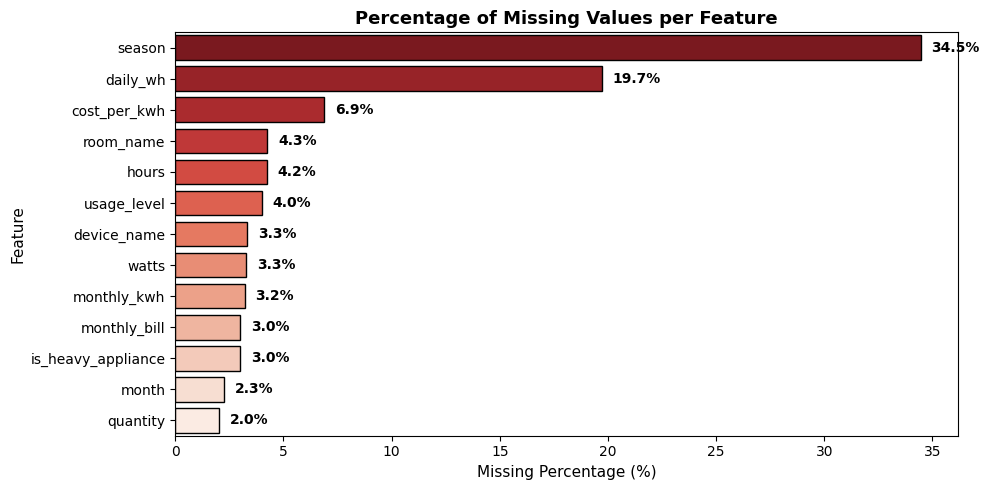

In [124]:
plt.figure(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Missing Values'] > 0]
sns.barplot(
    data=cols_with_missing,
    x='Missing Percentage (%)',
    y='Column',
    palette='Reds_r',
    edgecolor='black'
)
plt.title('Percentage of Missing Values per Feature', fontsize=13, fontweight='bold')
plt.xlabel('Missing Percentage (%)', fontsize=11)
plt.ylabel('Feature', fontsize=11)

for index, value in enumerate(cols_with_missing['Missing Percentage (%)']):
    plt.text(value + 0.5, index, f"{value:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** The bar chart ranks the affected columns by missing percentage, making it easy to see which features will need the most attention during imputation. None of the missing percentages are extreme enough (no column is mostly empty) to justify dropping a whole feature — imputation is the right strategy here.


In [125]:
df.describe()

,setup_id,monthly_bill,cost_per_kwh,daily_wh
count,8394.000000,8.141000e+03,7.815000e+03,6.739000e+03
mean,506.982011,1.269152e+04,3.245706e+03,2.005410e+04
std,285.695787,1.869173e+05,1.567229e+05,3.303211e+05
min,1.000000,8.450000e+00,7.970000e+00,-2.187900e+05
25%,259.000000,1.200000e+02,8.000000e+00,4.779000e+02
50%,507.000000,3.074400e+02,8.000000e+00,1.293600e+03
75%,749.000000,7.956000e+02,8.000000e+00,3.682050e+03
max,1000.000000,8.462160e+06,8.000000e+06,2.419200e+07


**Interpretation:** `df.describe()` only summarizes the columns already stored as numeric (`monthly_bill`, `cost_per_kwh`, `daily_wh`, plus `setup_id`). The scales differ substantially between features (e.g. `daily_wh` vs `cost_per_kwh`), which is exactly the kind of situation feature scaling (later, `RobustScaler`) is meant to address.


In [126]:
df.duplicated().sum()

np.int64(97)

**Interpretation:** A non-zero duplicate count confirms that some rows are exact repeats of others. These duplicates, along with all other deterministic cleaning steps, are handled in the **Basic Data Cleaning** section below.

## 4. Basic Data Cleaning

This section applies only **deterministic** cleaning rules — steps that do not learn any statistic or mapping from the data and therefore do not require fitting on a training split. This includes: removing duplicates, dropping the non-predictive identifier column, standardizing inconsistent categorical/text values, converting numeric-looking text columns to real numeric dtypes, and nulling out invalid/impossible/outlier values via fixed rules.

Anything that *fits* a statistic or a mapping from the dataset (imputers, encoders, the scaler) is deliberately **not** done here — those live in the **Preprocessing** section, fit on `X_train` only, after the train/test split.


In [127]:
df.drop_duplicates(keep='first',inplace=True)
df.reset_index(drop=True, inplace=True)

**Interpretation:** A non-zero duplicate count confirms that some rows are exact repeats of others (likely from data collection/merging issues). These are removed, since duplicate rows would otherwise bias both the EDA and the model training.

In [128]:
df.drop(['setup_id'], axis=1, inplace=True)

**Interpretation:** `setup_id` is a unique row identifier with no predictive value (it does not describe the device, the usage, or the consumption), so it is dropped before any further analysis or modeling.

### 4.1 Standardizing categorical text & converting numeric-looking columns

Several numeric-looking columns (`watts`, `hours`, `quantity`, `monthly_kwh`) are stored as `object` because the raw data contains placeholder strings (e.g. `"?"`, `"error"`, `"unknown"`) mixed with numbers. Categorical columns (`month`, `room_name`, `device_name`, `usage_level`) contain inconsistent casing/abbreviations. Each affected column is standardized individually below using explicit mapping dictionaries and rule-based fixes — all deterministic, none of it learned from the data's distribution (with the sole, flagged exception of the IQR-based `cost_per_kwh` bound, discussed below).

In [11]:
fig = make_subplots(rows=1, cols=2,subplot_titles=("Unique values per Categorical feature", "Unique values per Numerical feature"))

for col_type, col, color in [("exclude", 1, '#016CC9'), ("include", 2, '#DEB078')]:
    temp_data = df.select_dtypes(**{col_type: "number"}).nunique().sort_values()
    fig.add_trace(go.Bar(x=temp_data.index, y=temp_data.values, marker=dict(color=color)), row=1, col=col)

fig.show()

In [12]:
columns = df.select_dtypes(include="object").columns.tolist()


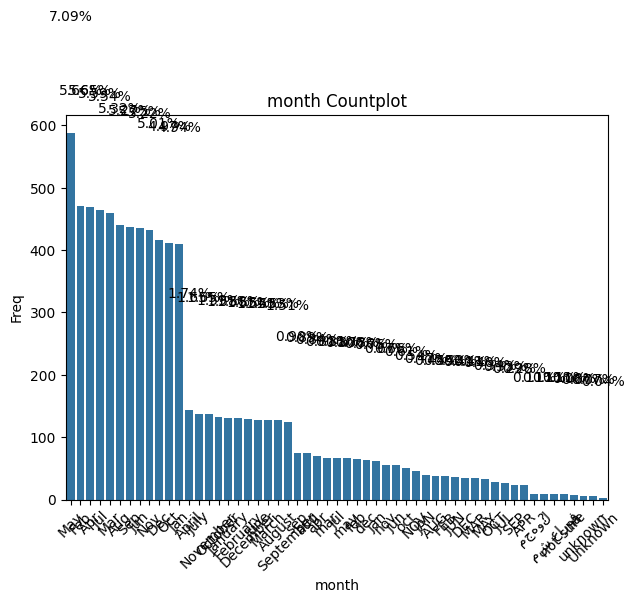

,count,Percentage
month,,
May,588,7.09
Feb,470,5.66
Apr,469,5.65
Jul,464,5.59
Mar,460,5.54
Aug,441,5.32
Sep,437,5.27
Jun,436,5.25
Nov,433,5.22


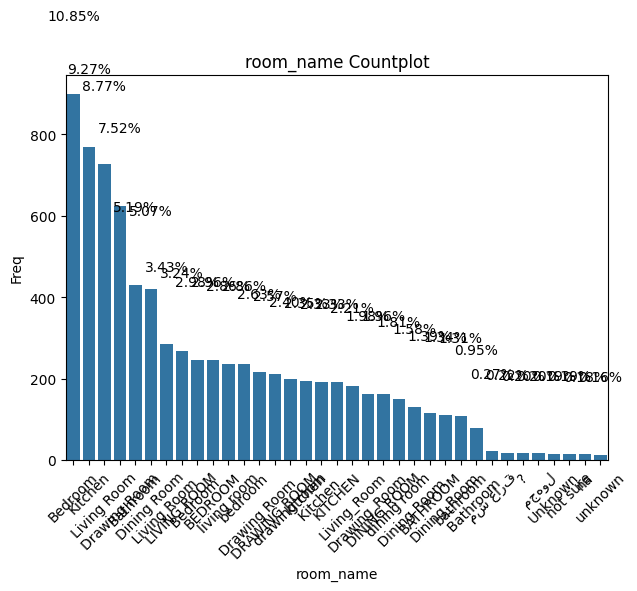

,count,Percentage
room_name,,
Bedroom,900,10.85
Kitchen,769,9.27
Living Room,728,8.77
Drawing Room,624,7.52
Bathroom,431,5.19
Dining Room,421,5.07
Living Room,285,3.43
LIVING ROOM,269,3.24
Bedroom,247,2.98


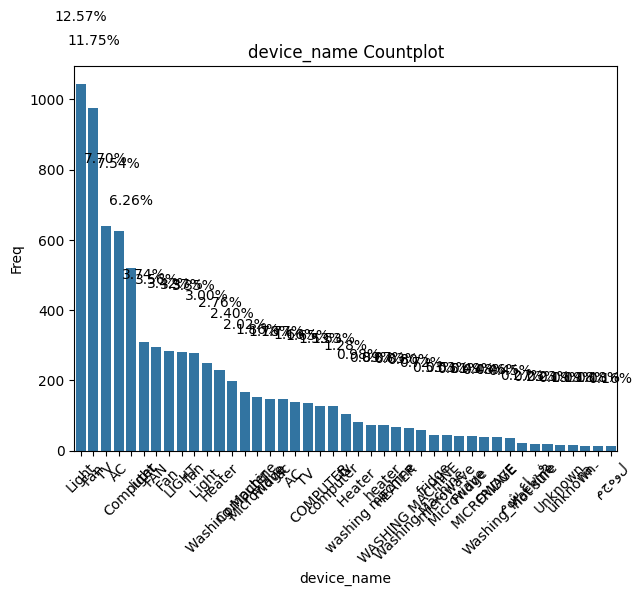

,count,Percentage
device_name,,
Light,1043,12.57
Fan,975,11.75
TV,639,7.70
AC,626,7.54
Computer,519,6.26
light,310,3.74
FAN,295,3.56
Fan,284,3.42
LIGHT,280,3.37


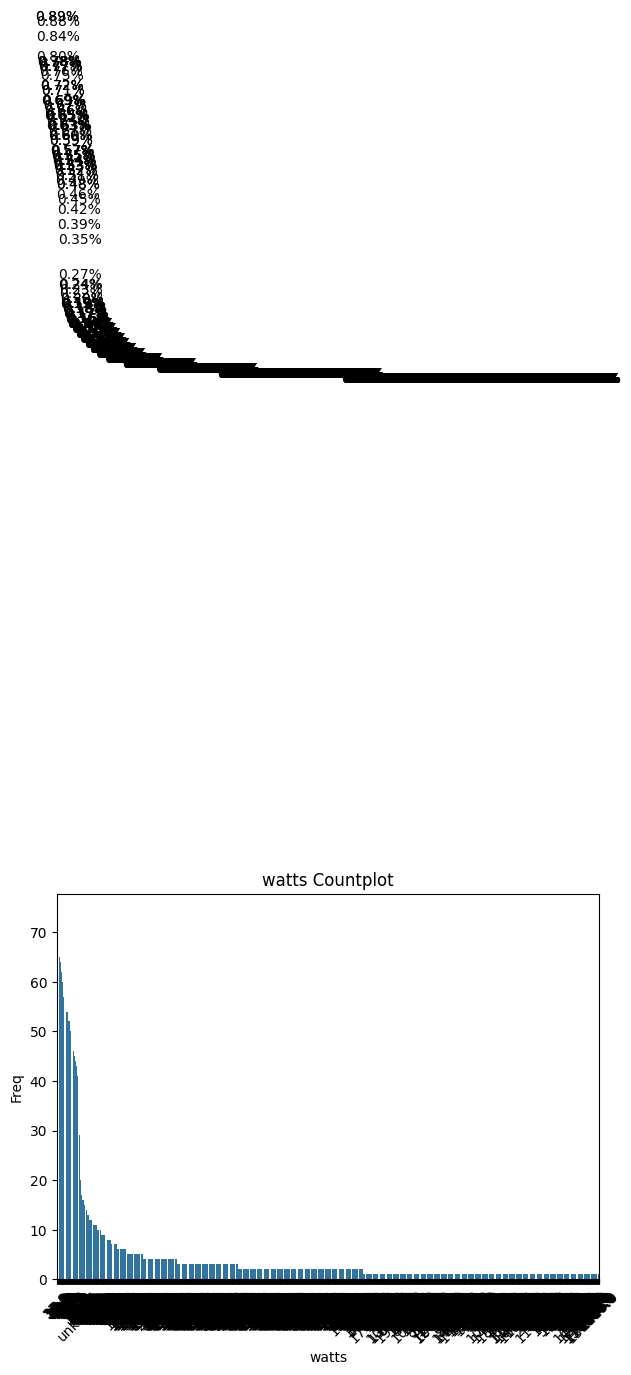

,count,Percentage
watts,,
37.0,74,0.89
36.0,74,0.89
14.0,73,0.88
16.0,70,0.84
27.0,66,0.80
...,...,...
1257.0,1,0.01
1867.0,1,0.01
1213.0,1,0.01


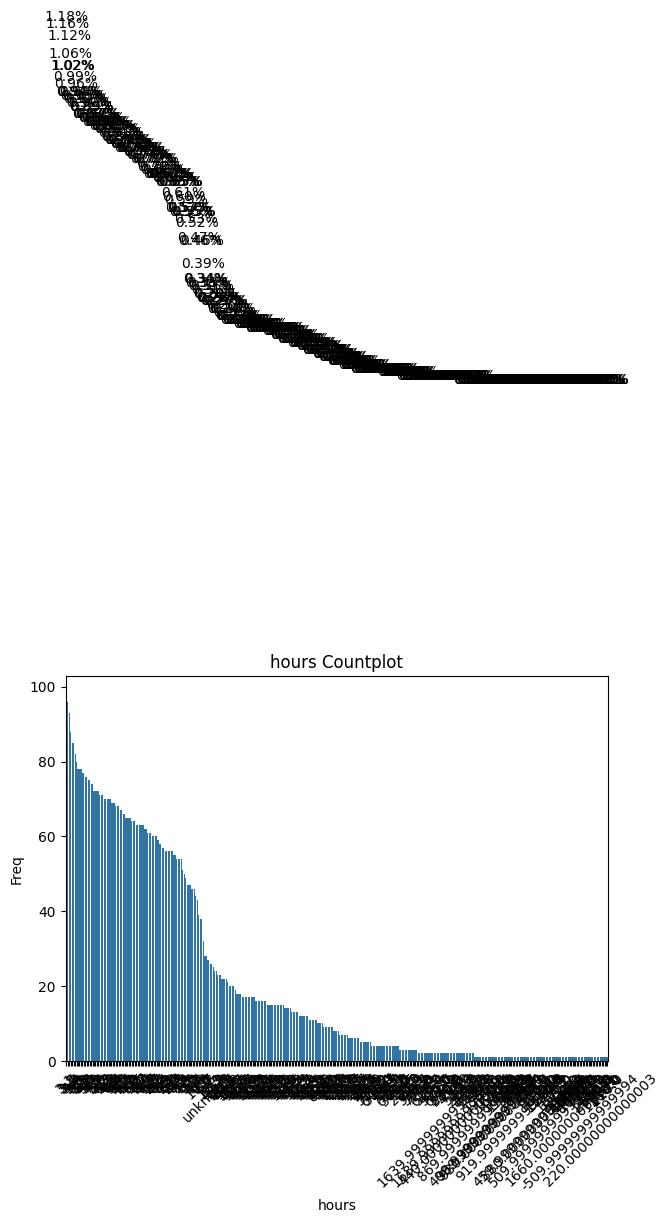

,count,Percentage
hours,,
3.1,98,1.18
3.8,96,1.16
3.7,93,1.12
3.9,88,1.06
4.4,85,1.02
...,...,...
1180.0,1,0.01
-1.8,1,0.01
140.0,1,0.01


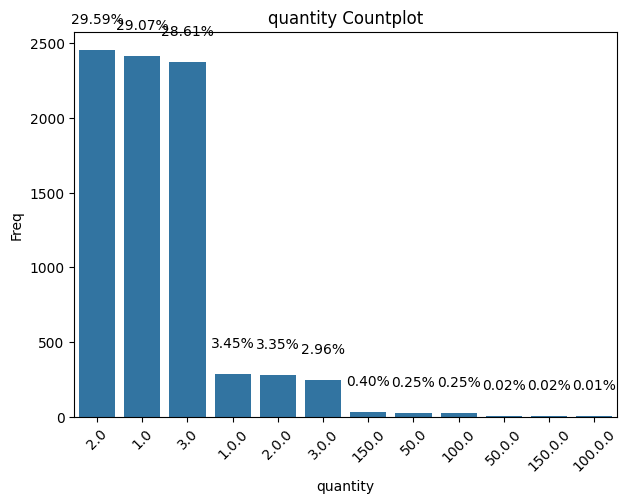

,count,Percentage
quantity,,
2.0,2455,29.59
1.0,2412,29.07
3.0,2374,28.61
1.0.0,286,3.45
2.0.0,278,3.35
3.0.0,246,2.96
150.0,33,0.40
50.0,21,0.25
100.0,21,0.25


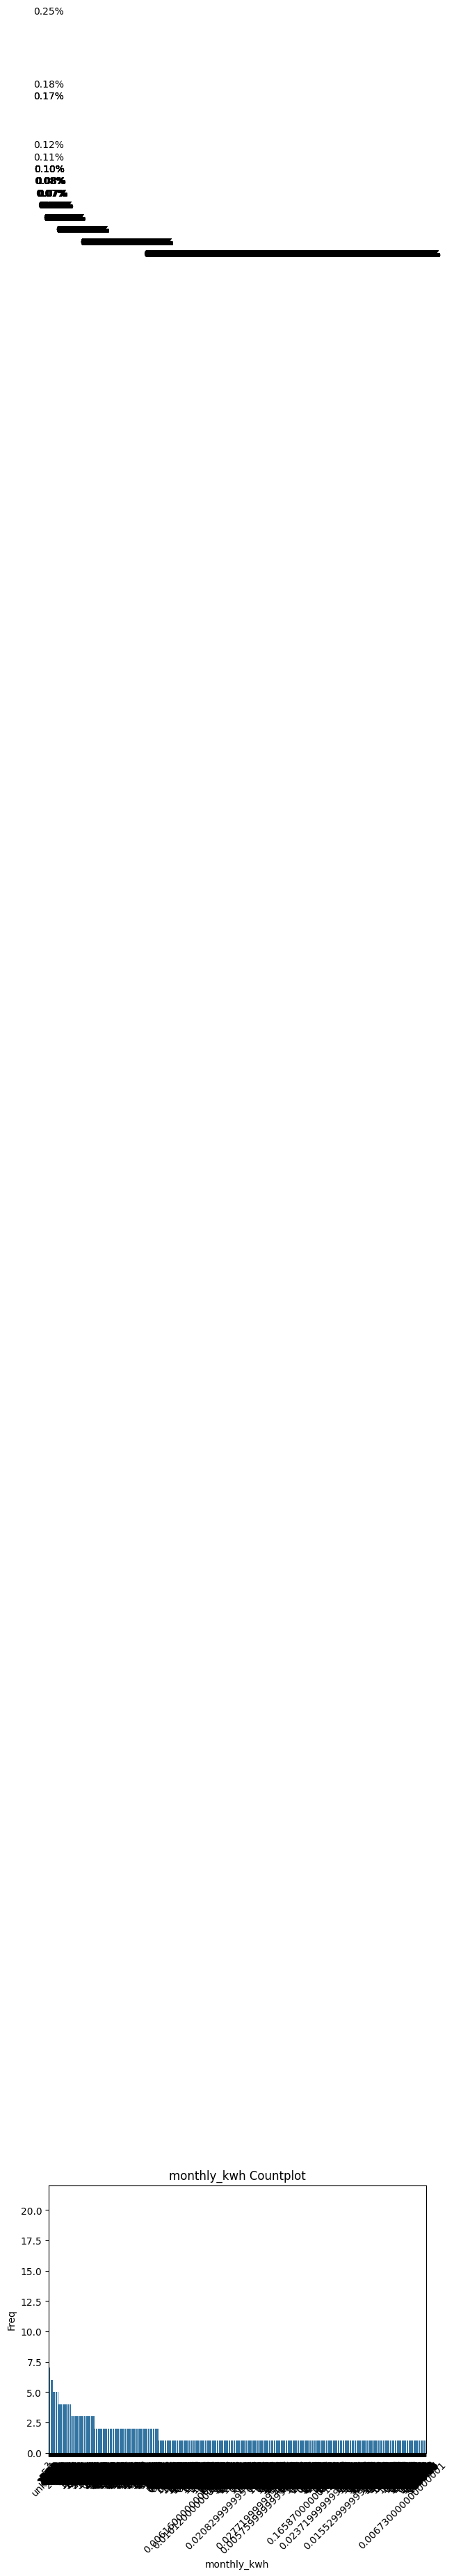

,count,Percentage
monthly_kwh,,
?,21,0.25
error,15,0.18
-,14,0.17
unknown,14,0.17
3.17,10,0.12
...,...,...
31.62,1,0.01
300.83,1,0.01
208.85,1,0.01


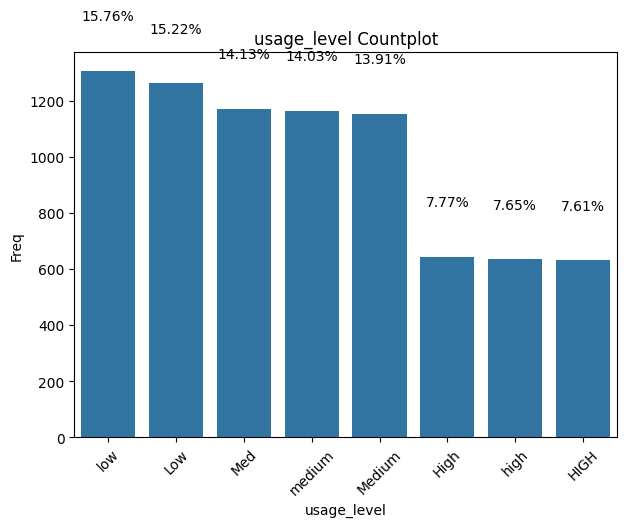

,count,Percentage
usage_level,,
low,1308,15.76
Low,1263,15.22
Med,1172,14.13
medium,1164,14.03
Medium,1154,13.91
High,645,7.77
high,635,7.65
HIGH,631,7.61


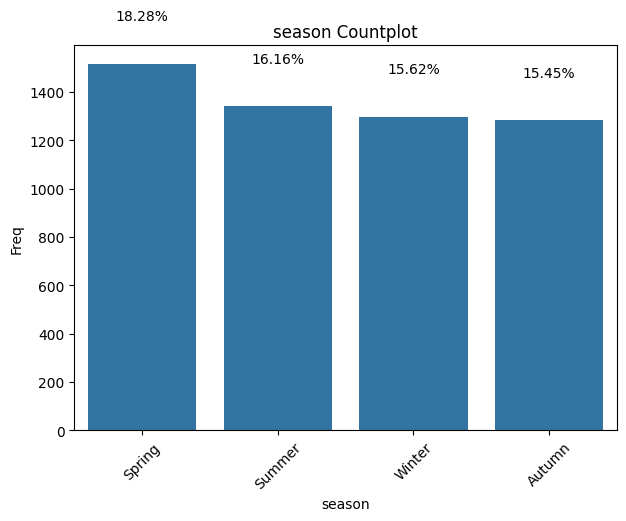

,count,Percentage
season,,
Spring,1517,18.28
Summer,1341,16.16
Winter,1296,15.62
Autumn,1282,15.45


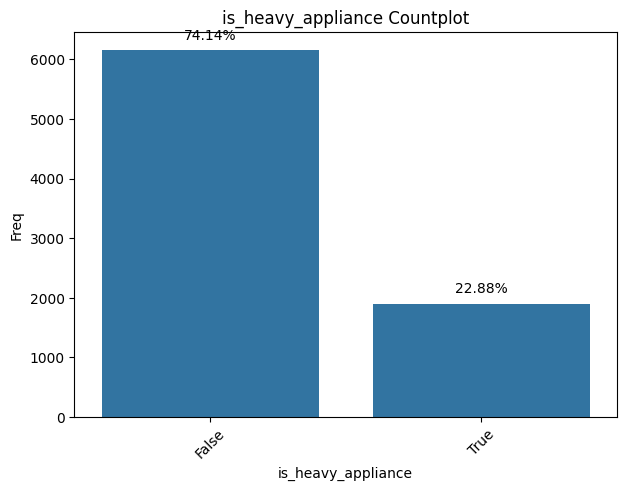

,count,Percentage
is_heavy_appliance,,
False,6151,74.14
True,1898,22.88


In [13]:
for col in columns:
    work_values = df[col].value_counts()
    plt.figure(figsize=(7, 5))
    plt.title(f"{col} Countplot")
    sns.countplot(data=df,x=col,order=work_values.index)
    plt.xlabel(col)
    plt.ylabel("Freq")
    plt.tick_params(axis='x', labelrotation=45)
    for idx in range(len(work_values)):
        text = f"{work_values.values[idx] * 100 / len(df):.2f}%"
        plt.text(x=idx,y=work_values.values[idx] + 180,s=text,ha='center')
    plt.show()
    freq = pd.DataFrame(work_values)
    freq["Percentage"] = round(freq["count"] * 100 / len(df),2)
    display(freq)

In [14]:
df['month'] = df['month'].astype(str).str.strip().str.lower()


In [15]:

month_map = {
    'jan': 'January',
    'january': 'January',

    'feb': 'February',
    'february': 'February',

    'mar': 'March',
    'march': 'March',

    'apr': 'April',
    'april': 'April',

    'may': 'May',

    'jun': 'June',
    'june': 'June',

    'jul': 'July',
    'july': 'July',

    'aug': 'August',
    'august': 'August',

    'sep': 'September',
    'september': 'September',

    'oct': 'October',
    'october': 'October',

    'nov': 'November',
    'november': 'November',

    'dec': 'December',
    'december': 'December'
}

df['month'] = df['month'].map(month_map)

In [16]:
for value in sorted(df["month"].astype(str).unique()):
    print(value)

April
August
December
February
January
July
June
March
May
November
October
September
nan


**Interpretation:** After lower-casing/stripping and mapping abbreviations to full names, `month` now contains a clean, consistent set of 12 month names.

In [17]:
df['room_name'] = (
    df['room_name']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('_', ' ', regex=False)
)

In [18]:
room_map = {
    'bedroom': 'Bedroom',
    'kitchen': 'Kitchen',
    'living room': 'Living Room',
    'drawing room': 'Drawing Room',
    'bathroom': 'Bathroom',
    'dining room': 'Dining Room'
}

df['room_name'] = df['room_name'].map(room_map)

In [19]:
for value in sorted(df["room_name"].astype(str).unique()):
    print(value)

Bathroom
Bedroom
Dining Room
Drawing Room
Kitchen
Living Room
nan


**Interpretation:** `room_name` values are normalized (case, whitespace, underscores) and mapped to a clean, consistent set of room labels.

In [20]:
df['device_name'] = (
    df['device_name']
    .astype('string')
    .str.strip()
    .str.lower()
    .str.replace('_', ' ', regex=False)
)

In [21]:
device_map = {
    'light': 'Light',
    'fan': 'Fan',
    'tv': 'TV',
    'ac': 'AC',
    'computer': 'Computer',
    'heater': 'Heater',
    'washing machine': 'Washing Machine',
    'microwave': 'Microwave',
    'fridge': 'Fridge'
}

df['device_name'] = df['device_name'].map(device_map)

**Interpretation:** `device_name` is cleaned the same way as `room_name` — lower-cased, stripped, underscores replaced with spaces, then mapped to a consistent, human-readable set of device categories.

In [22]:
for value in sorted(df["watts"].astype(str).unique()):
    print(value)

-
-10.0
-1029.0
-1033.0
-106.0
-108.0
-11.0
-115.0
-118.0
-119.0
-1202.0
-1221.0
-1236.0
-124.0
-1253.0
-127.0
-128.0
-13.0
-1309.0
-1319.0
-1325.0
-134.0
-135.0
-1367.0
-1368.0
-1372.0
-1378.0
-1381.0
-14.0
-141.0
-1438.0
-144.0
-1449.0
-1455.0
-1516.0
-152.0
-156.0
-1563.0
-160.0
-164.0
-165.0
-1711.0
-1720.0
-1726.0
-1741.0
-179.0
-18.0
-180.0
-1841.0
-189.0
-19.0
-1904.0
-1911.0
-1926.0
-1970.0
-1976.0
-1995.0
-20.0
-203.0
-21.0
-213.0
-219.0
-23.0
-233.0
-24.0
-241.0
-244.0
-26.0
-27.0
-270.0
-282.0
-29.0
-30.0
-301.0
-31.0
-32.0
-321.0
-33.0
-330.0
-34.0
-35.0
-36.0
-360.0
-38.0
-39.0
-397.0
-50.0
-51.0
-529.0
-56.0
-58.0
-59.0
-60.0
-63.0
-64.0
-644.0
-65.0
-67.0
-698.0
-70.0
-701.0
-72.0
-73.0
-738.0
-745.0
-75.0
-77.0
-78.0
-79.0
-81.0
-82.0
-83.0
-84.0
-85.0
-86.0
-87.0
-88.0
-90.0
-91.0
-972.0
-989.0
10.0
100.0
1000.0
1001.0
1002.0
1003.0
1004.0
1006.0
1007.0
101.0
1010.0
1011.0
1012.0
1013.0
1015.0
1016.0
1017.0
1018.0
101800.0
102.0
1020.0
10200.0
1022.0
1023.0
1024.0
1025

**Interpretation:** The raw `watts` column mixes valid numbers with placeholder strings such as `"?"`, `"error"`, `"unknown"`, `"-"`. These need to be converted to `NaN` before the column can be treated as numeric.

In [23]:
df['watts'] = df['watts'].replace(
    ['?', 'error', 'unknown', '-'],
    np.nan
)

df['watts'] = pd.to_numeric(df['watts'], errors='coerce')

**Interpretation:** Placeholder tokens have been replaced with `NaN` and the column coerced to numeric with `pd.to_numeric(errors='coerce')`, so any leftover unparsable text also becomes `NaN`.

In [24]:
df['watts'].describe()

,watts
count,7953.000000
mean,939.294103
std,8065.286016
min,-1995.000000
25%,50.000000
50%,95.000000
75%,539.000000
max,197300.000000


In [25]:
(df['watts'] < 0).sum()

np.int64(162)

In [26]:
df.loc[df['watts'] > 10000, 'watts'].value_counts()

,count
watts,
10200.0,2
61800.0,1
23300.0,1
118400.0,1
14200.0,1
38200.0,1
14600.0,1
143300.0,1
22200.0,1


In [27]:
df[df['watts'] < 0]['watts'].describe()

,watts
count,162.000000
mean,-409.302469
std,586.700905
min,-1995.000000
25%,-615.250000
50%,-87.000000
75%,-39.000000
max,-10.000000


In [28]:
df.loc[df['watts'] >= 10000, 'watts'] = df.loc[
    df['watts'] >= 10000, 'watts'
] / 100

In [29]:
df.loc[df['watts'] < 0, 'watts'] = np.nan

**Interpretation:** Two data-quality issues were found in `watts`: (1) some negative values, which are physically impossible for a power rating and are set to `NaN`, and (2) some implausibly large values (≥10,000 W) that look like they are off by a factor of 100 (likely a unit/formatting error) — these are corrected by dividing by 100 rather than discarded, since the underlying reading still carries information.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8297 entries, 0 to 8296
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               8052 non-null   object 
 1   room_name           7810 non-null   object 
 2   device_name         7886 non-null   object 
 3   watts               7791 non-null   float64
 4   hours               7944 non-null   object 
 5   quantity            8131 non-null   object 
 6   monthly_kwh         8036 non-null   object 
 7   monthly_bill        8047 non-null   float64
 8   cost_per_kwh        7730 non-null   float64
 9   daily_wh            6661 non-null   float64
 10  usage_level         7972 non-null   object 
 11  season              5436 non-null   object 
 12  is_heavy_appliance  8049 non-null   object 
dtypes: float64(4), object(9)
memory usage: 842.8+ KB


**Interpretation:** `watts` is now a proper numeric column with invalid/negative entries removed and scale outliers corrected.

In [31]:
for value in sorted(df["hours"].astype(str).unique()):
    print(value)

-
-0.1
-0.2
-0.6
-1.4
-1.8
-10.1
-12.5
-13.1
-14.0
-15.8
-16.0
-17.6
-2.0
-2.1
-2.7
-2.8
-2.9
-21.3
-21.6
-21.7
-21.9
-3.2
-3.3
-3.4
-3.6
-3.8
-3.9
-4.0
-4.1
-4.5
-4.7
-5.2
-5.3
-5.4
-5.6
-5.7
-5.8
-5.9
-509.99999999999994
-6.1
-6.3
-7.0
-7.2
-7.9
-8.1
-8.4
-8.7
-9.0
-9.2
-9.7
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0
1.1
1.2
1.3
1.4
1.5
1.6
1.7
1.8
1.9
10.0
10.1
10.2
10.3
10.4
10.5
10.6
10.7
10.8
10.9
1060.0
11.0
11.1
11.2
11.3
11.4
11.5
11.6
11.7
11.8
11.9
1170.0
1180.0
12.0
12.1
12.2
12.3
12.4
12.5
12.6
12.7
12.8
12.9
1200.0
1260.0
13.0
13.1
13.2
13.3
13.4
13.5
13.6
13.7
13.8
13.9
1320.0
1340.0
14.0
14.1
14.2
14.3
14.4
14.5
14.6
14.7
14.8
14.9
140.0
1430.0
1480.0
15.0
15.1
15.2
15.3
15.4
15.5
15.6
15.7
15.8
15.9
150.0
1510.0
1540.0
16.0
16.1
16.2
16.3
16.4
16.5
16.6
16.7
16.8
16.9
1600.0
1639.9999999999998
1660.0000000000002
1670.0
1689.9999999999998
17.0
17.1
17.2
17.3
17.4
17.5
17.6
17.7
17.8
17.9
170.0
1750.0
18.0
18.1
18.2
18.3
18.4
18.5
18.6
18.7
18.8
18.9
1870.0
19.0
19.1
19.2
1

**Interpretation:** Like `watts`, the `hours` column contains placeholder strings alongside numeric values and needs the same clean-then-convert treatment.

In [32]:
df["hours"] = df["hours"].replace(
    ["?", "error", "unknown", "nan"],
    np.nan
)
df["hours"] = pd.to_numeric(df["hours"], errors="coerce")
print(df["hours"].describe())
print("Missing:", df["hours"].isna().sum())

count    7867.000000
mean       17.655104
std       103.186082
min      -510.000000
25%         3.500000
50%         6.200000
75%         9.400000
max      2060.000000
Name: hours, dtype: float64
Missing: 430


In [33]:
print(df[df["hours"] < 0]["hours"].describe())

count     66.000000
mean     -15.231818
std       62.114332
min     -510.000000
25%       -9.575000
50%       -5.800000
75%       -3.450000
max       -0.100000
Name: hours, dtype: float64


In [34]:
print(df[df["hours"] > 24]["hours"].describe())

count     119.000000
mean      711.596639
std       461.162832
min        30.000000
25%       360.000000
50%       600.000000
75%       895.000000
max      2060.000000
Name: hours, dtype: float64


In [35]:
df.loc[df["hours"] < 0, "hours"] = np.nan

In [36]:
print("Negative:", (df["hours"] < 0).sum())
print("0-24:", ((df["hours"] >= 0) & (df["hours"] <= 24)).sum())
print("24-100:", ((df["hours"] > 24) & (df["hours"] <= 100)).sum())
print("100-500:", ((df["hours"] > 100) & (df["hours"] <= 500)).sum())
print("500+:", (df["hours"] > 500).sum())

Negative: 0
0-24: 7682
24-100: 3
100-500: 42
500+: 74


In [37]:
df.loc[df["hours"] > 24, "hours"] = np.nan

**Interpretation:** `hours` represents average **daily** usage hours, so valid values must fall within `[0, 24]`. Placeholder strings were converted to `NaN`, negative values were set to `NaN` (impossible), and values above 24 were also set to `NaN` (impossible for a daily-hours field) rather than corrected, since there is no reliable rule (like the ÷100 case for `watts`) to recover the true value.

In [38]:
df["quantity"] = df["quantity"].astype(str).str.replace(".0.0", ".0", regex=False)

df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

**Interpretation:** `quantity` had a formatting artifact (a duplicated `".0.0"` suffix) which is fixed with a targeted string replacement before converting to numeric.

In [39]:
print(df[df["quantity"] > 3]["quantity"].value_counts().sort_index())

quantity
50.0     23
100.0    22
150.0    35
Name: count, dtype: int64


In [40]:
print(df["quantity"].value_counts().sort_index())

quantity
1.0      2698
2.0      2733
3.0      2620
50.0       23
100.0      22
150.0      35
Name: count, dtype: int64


In [41]:
print(df['quantity'].describe())
print("\nOutliers (quantity > 10):")
print(df.loc[df['quantity'] > 10, 'quantity'].value_counts())


count    8131.000000
mean        3.028410
std        11.242811
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       150.000000
Name: quantity, dtype: float64

Outliers (quantity > 10):
quantity
150.0    35
50.0     23
100.0    22
Name: count, dtype: int64


In [42]:
df.loc[df['quantity'] > 10, 'quantity'] = np.nan
print("Missing values in quantity after fix:", df['quantity'].isna().sum())


Missing values in quantity after fix: 246


**Interpretation:** After inspecting the distribution, `quantity` values above 10 are treated as unrealistic (a room is unlikely to contain more than 10 units of the same appliance) and are set to `NaN` to be handled later by imputation.

### 4.2 `cost_per_kwh` outlier bound (rule-based, computed once and persisted)

An IQR-based rule (`Q1 - 1.5*IQR` / `Q3 + 1.5*IQR`) is used for `cost_per_kwh` since it doesn't have an obvious physical bound like `hours` does. This bound is computed **once**, here, on the full cleaned dataset (exactly as in the original notebook — nothing about this rule is changed). Because a single new user input at inference time has no distribution of its own to compute quantiles from, the resulting `lower_bound`/`upper_bound` values are captured and saved as a deployment artifact (`cost_per_kwh_bounds.pkl`) so the exact same rule can be re-applied to new data during Streamlit inference, instead of being recomputed (which would be impossible for a single row anyway).

In [43]:
print(df['cost_per_kwh'].describe())
Q1 = df['cost_per_kwh'].quantile(0.25)
Q3 = df['cost_per_kwh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nNormal range based on IQR: [{lower_bound:.4f}, {upper_bound:.4f}]")
n_outliers = ((df['cost_per_kwh'] < lower_bound) | (df['cost_per_kwh'] > upper_bound)).sum()
print("Outliers count:", n_outliers)
df.loc[(df['cost_per_kwh'] < lower_bound) | (df['cost_per_kwh'] > upper_bound), 'cost_per_kwh'] = np.nan
print("Missing values in cost_per_kwh after fix:", df['cost_per_kwh'].isna().sum())


count    7.730000e+03
mean     2.245347e+03
std      1.286752e+05
min      7.970000e+00
25%      8.000000e+00
50%      8.000000e+00
75%      8.000000e+00
max      8.000000e+06
Name: cost_per_kwh, dtype: float64

Normal range based on IQR: [8.0000, 8.0000]
Outliers count: 525
Missing values in cost_per_kwh after fix: 1092


In [44]:
cost_per_kwh_bounds = {'lower_bound': lower_bound, 'upper_bound': upper_bound}

**Interpretation:** For `cost_per_kwh`, detected outliers (values outside the IQR-based normal range) are set to `NaN`. The bound itself is saved so that the identical rule (not a re-derived one) is used for any future single-row input.

In [45]:
for value in sorted(df["monthly_kwh"].astype(str).unique()):
    print(value)

-
0.00335
0.004
0.00437
0.0048
0.0057599999999999995
0.0061600000000000005
0.00621
0.0066
0.006730000000000001
0.00679
0.00714
0.01077
0.01122
0.012
0.01248
0.01274
0.01332
0.01452
0.0154
0.015529999999999999
0.01566
0.016120000000000002
0.01706
0.01747
0.01755
0.01835
0.0198
0.0205
0.02066
0.02072
0.020829999999999998
0.02141
0.02142
0.02343
0.023719999999999998
0.02427
0.02767
0.027719999999999998
0.02935
0.02966
0.02981
0.03478
0.03499
0.0361
0.03978
0.04176
0.04512
0.04765
0.05022
0.05049
0.05821
0.06778
0.06966
0.07267
0.08058
0.08064
0.08633
0.10065
0.10296
0.11304
0.1192
0.1205
0.12262
0.13025
0.13306
0.14238
0.14342
0.16408
0.16587000000000002
0.19782
0.24302
0.28346
0.43963
0.59787
0.66265
0.93375
1.06
1.08
1.17
1.19
1.21
1.22
1.29
1.32
1.35
1.36
1.4
1.43
1.44
1.47
1.48
1.49
1.51
1.53
1.54
1.56
1.58
1.6
1.62
1.63
1.68
1.75
1.76
1.78
1.79
1.8
1.81
1.82
1.83
1.84
1.86
1.89
1.91
1.92
1.93
1.94
1.99
10.01
10.02
10.04
10.06
10.08
10.1
10.12
10.13
10.14
10.15
10.16
10.18
10.2
10.21


**Interpretation:** The target column `monthly_kwh` also contains placeholder strings and needs cleaning before it can be used as the regression target.

In [46]:
df["monthly_kwh"] = df["monthly_kwh"].replace(["?", "error", "unknown", "-"], np.nan)
df["monthly_kwh"] = pd.to_numeric(df["monthly_kwh"], errors="coerce")
df = df.dropna(subset=['monthly_kwh'])
df.reset_index(drop=True, inplace=True)
print(df["monthly_kwh"].isnull().sum())

0


**Interpretation:** Because `monthly_kwh` is the **target variable**, rows where it cannot be recovered (still `NaN` after coercion) are dropped entirely rather than imputed — imputing the target would leak an assumption about the answer into the data used to evaluate the model. (This step only applies to training data — a Streamlit inference request has no target to validate.)

In [47]:
df["usage_level"] = df["usage_level"].astype(str).str.lower()

df["usage_level"] = df["usage_level"].replace({
    "med": "medium"
})

In [48]:
df['usage_level'] = df['usage_level'].replace('nan', np.nan)

**Interpretation:** `usage_level` only needed a minor fix — lower-casing, mapping the abbreviation `"med"` to `"medium"`, and restoring the literal string `"nan"` (an artifact of `astype(str)`) back to a real missing value — after which it holds a clean set of `low` / `medium` / `high` labels (plus genuine missing values, to be imputed later).

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               7736 non-null   object 
 1   room_name           7503 non-null   object 
 2   device_name         7582 non-null   object 
 3   watts               7487 non-null   float64
 4   hours               7388 non-null   float64
 5   quantity            7734 non-null   float64
 6   monthly_kwh         7972 non-null   float64
 7   monthly_bill        7730 non-null   float64
 8   cost_per_kwh        7205 non-null   float64
 9   daily_wh            6413 non-null   float64
 10  usage_level         7972 non-null   object 
 11  season              5214 non-null   object 
 12  is_heavy_appliance  7734 non-null   object 
dtypes: float64(7), object(6)
memory usage: 809.8+ KB


In [50]:
df.duplicated().sum()

np.int64(111)

In [51]:
df.drop_duplicates(keep='first',inplace=True)
df.reset_index(drop=True, inplace=True)

**Interpretation:** Cleaning can introduce new duplicate rows (e.g. two originally-different rows collapse to the same values once invalid entries become `NaN`), so duplicates are checked and removed once more. This closes the data-cleaning stage: text values are standardized, numeric columns are properly typed, impossible values are removed, and the target column has no missing values.

/tmp/ipykernel_1168/4286529229.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




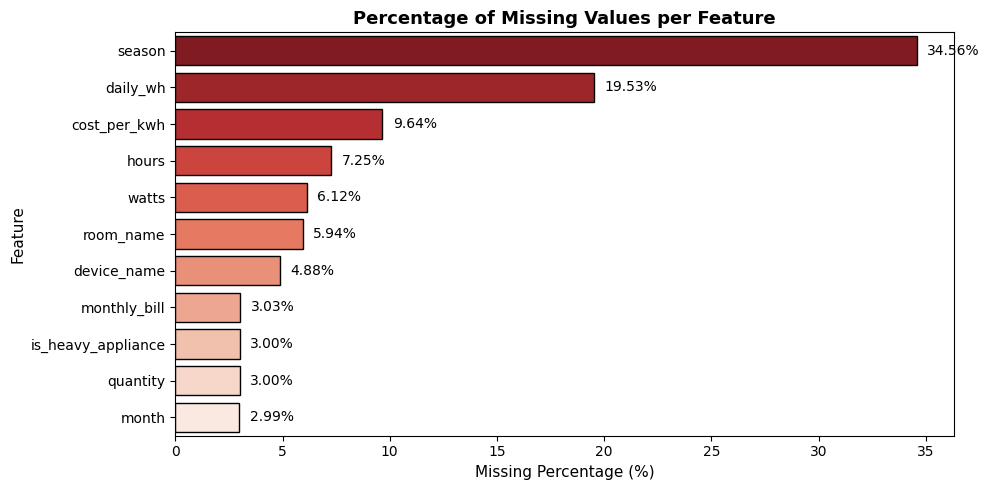

In [52]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_count.values,
    'Missing Percentage (%)': missing_percent.values
}).sort_values(by='Missing Percentage (%)', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Missing Values'] > 0]

if cols_with_missing.empty:
    print("Empty")
else:
    sns.barplot(
        data=cols_with_missing,
        x='Missing Percentage (%)',
        y='Column',
        palette='Reds_r',
        edgecolor='black'
    )
    plt.title('Percentage of Missing Values per Feature', fontsize=13, fontweight='bold')
    plt.xlabel('Missing Percentage (%)', fontsize=11)
    plt.ylabel('Feature', fontsize=11)

    for index, value in enumerate(cols_with_missing['Missing Percentage (%)']):
        plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

    plt.tight_layout()
    plt.show()


**Interpretation:** This missing-value check reflects the state of the data **after** cleaning: some columns now have additional `NaN`s introduced by the invalid-value/outlier removal above. These remaining gaps are intentionally left for the imputation step later in the modeling pipeline, so the same imputers can be fit on the training split only (avoiding data leakage) and reused at inference time.

### 4.3 Reusable cleaning function for deployment

The cell-by-cell cleaning above is what actually produced the `df` used for the rest of this notebook (it is executed once, in order). For the Streamlit app, the identical logic needs to run again on a single new raw input row. Rather than duplicating the transformations in a second place with the risk of drift, the exact same rules are captured below in one function, `apply_basic_cleaning`, which the final deployment test (Section 13) calls to simulate the real Streamlit workflow end-to-end.

In [53]:
def apply_basic_cleaning(df_raw, is_training=False, cost_bounds=None):
    d = df_raw.copy()

    if is_training:
        d.drop_duplicates(keep='first', inplace=True)
        d.reset_index(drop=True, inplace=True)

    if 'setup_id' in d.columns:
        d.drop(columns=['setup_id'], inplace=True)

    if 'month' in d.columns:
        d['month'] = d['month'].astype(str).str.strip().str.lower()
        d['month'] = d['month'].map(month_map)

    if 'room_name' in d.columns:
        d['room_name'] = (
            d['room_name'].astype(str).str.strip().str.lower().str.replace('_', ' ', regex=False)
        )
        d['room_name'] = d['room_name'].map(room_map)

    if 'device_name' in d.columns:
        d['device_name'] = (
            d['device_name'].astype('string').str.strip().str.lower().str.replace('_', ' ', regex=False)
        )
        d['device_name'] = d['device_name'].map(device_map)

    if 'watts' in d.columns:
        d['watts'] = d['watts'].replace(['?', 'error', 'unknown', '-'], np.nan)
        d['watts'] = pd.to_numeric(d['watts'], errors='coerce')
        d.loc[d['watts'] >= 10000, 'watts'] = d.loc[d['watts'] >= 10000, 'watts'] / 100
        d.loc[d['watts'] < 0, 'watts'] = np.nan

    if 'hours' in d.columns:
        d['hours'] = d['hours'].replace(['?', 'error', 'unknown', 'nan'], np.nan)
        d['hours'] = pd.to_numeric(d['hours'], errors='coerce')
        d.loc[d['hours'] < 0, 'hours'] = np.nan
        d.loc[d['hours'] > 24, 'hours'] = np.nan

    if 'quantity' in d.columns:
        d['quantity'] = d['quantity'].astype(str).str.replace('.0.0', '.0', regex=False)
        d['quantity'] = pd.to_numeric(d['quantity'], errors='coerce')
        d.loc[d['quantity'] > 10, 'quantity'] = np.nan

    if 'cost_per_kwh' in d.columns and cost_bounds is not None:
        lb, ub = cost_bounds['lower_bound'], cost_bounds['upper_bound']
        d.loc[(d['cost_per_kwh'] < lb) | (d['cost_per_kwh'] > ub), 'cost_per_kwh'] = np.nan

    if is_training and 'monthly_kwh' in d.columns:
        d['monthly_kwh'] = d['monthly_kwh'].replace(['?', 'error', 'unknown', '-'], np.nan)
        d['monthly_kwh'] = pd.to_numeric(d['monthly_kwh'], errors='coerce')
        d = d.dropna(subset=['monthly_kwh'])
        d.reset_index(drop=True, inplace=True)

    if 'usage_level' in d.columns:
        d['usage_level'] = d['usage_level'].astype(str).str.lower()
        d['usage_level'] = d['usage_level'].replace({'med': 'medium'})
        d['usage_level'] = d['usage_level'].replace('nan', np.nan)

    if is_training:
        d.drop_duplicates(keep='first', inplace=True)
        d.reset_index(drop=True, inplace=True)

    return d


**Verification:** this function is not re-run over the training `df` above (that would duplicate transformations unnecessarily) — it is only exercised later, in the final deployment test, to confirm it reproduces the same result as the manual steps.

## 5. Exploratory Data Analysis (EDA)

The cleaned dataset is now explored visually to understand feature distributions, relationships with the target (`monthly_kwh`), and correlations between features. Nothing in this section is used by the deployment pipeline — it is purely for understanding the data.

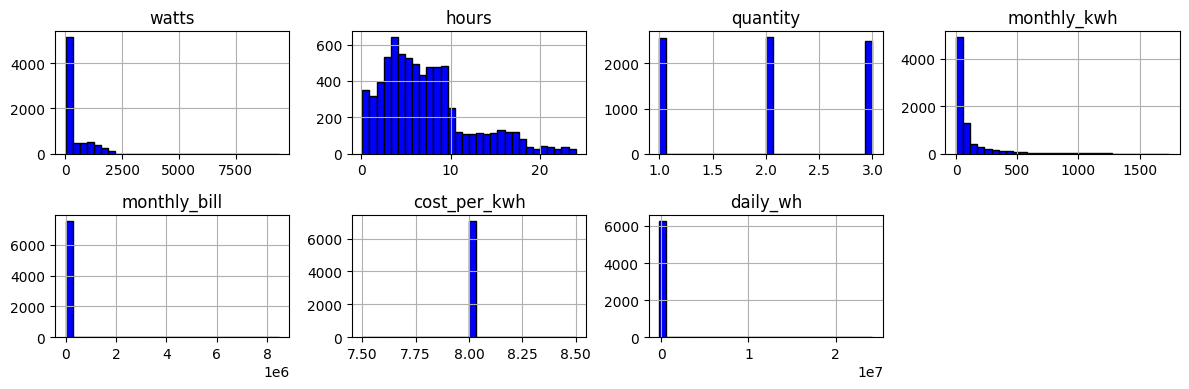

In [54]:
figsize_val=(12,4)
layout_val=(-1, 4)
df.hist(bins=30, figsize=figsize_val, layout=layout_val, edgecolor="black",color='blue')
plt.tight_layout()

**Interpretation:** The histograms of numeric features show the overall shape of each distribution (skew, spread, presence of long tails). This gives a first read on which features might benefit from scaling or transformation before modeling.


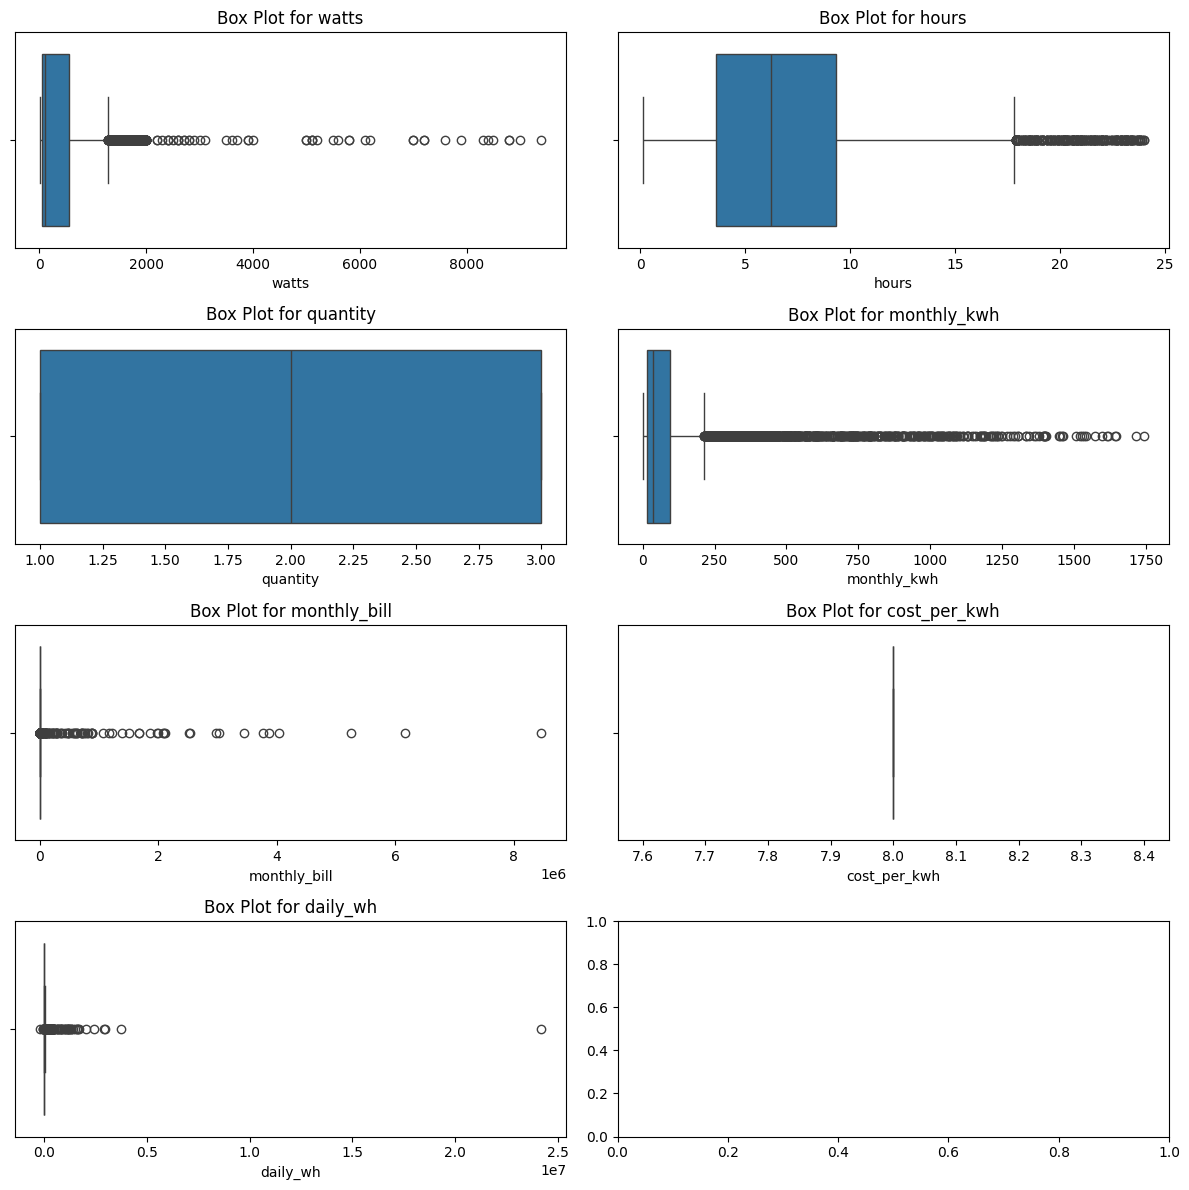

In [55]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 2, figsize=(12,12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot for {col}')
plt.tight_layout()
plt.show()

**Interpretation:** Looking at the numeric features individually confirms differences in scale and spread across columns (e.g. `watts` vs `hours` vs `cost_per_kwh`), reinforcing the need for feature scaling later in the pipeline.


/tmp/ipykernel_1168/2419583177.py:13: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



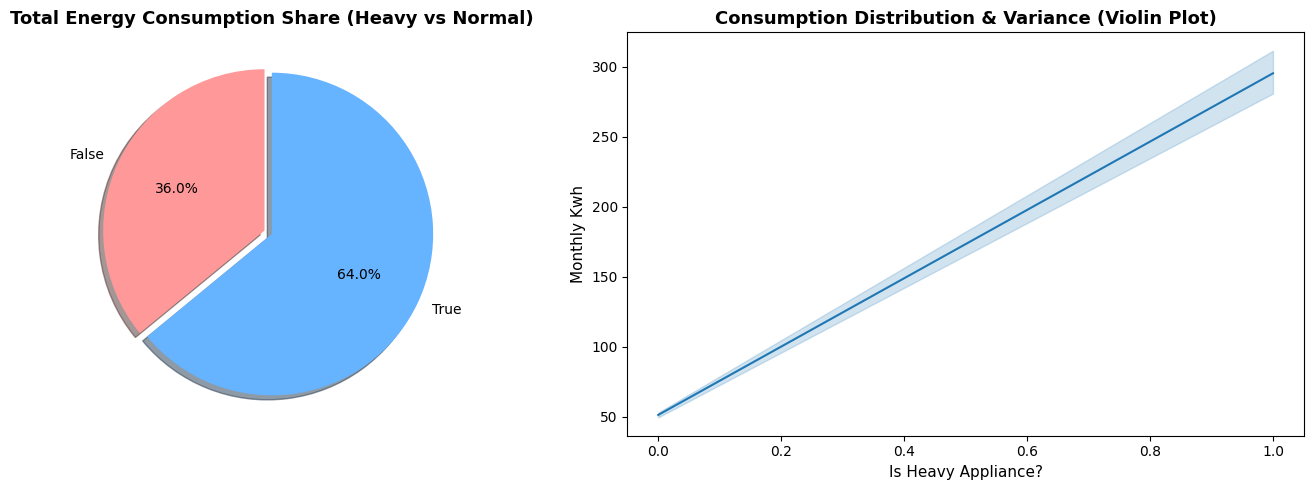

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
heavy_consumption = df.groupby('is_heavy_appliance')['monthly_kwh'].sum()
axes[0].pie(
    heavy_consumption,
    labels=heavy_consumption.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff'],
    explode=(0.05, 0),
    shadow=True
)
axes[0].set_title("Total Energy Consumption Share (Heavy vs Normal)", fontsize=13, fontweight='bold')
sns.lineplot(
    data=df,
    x='is_heavy_appliance',
    y='monthly_kwh',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title("Consumption Distribution & Variance (Violin Plot)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Is Heavy Appliance?", fontsize=11)
axes[1].set_ylabel("Monthly Kwh", fontsize=11)

plt.tight_layout()
plt.show()

**Interpretation:** The pie chart compares total `monthly_kwh` consumed by heavy vs. non-heavy appliances. If heavy appliances account for a disproportionate share of total consumption, `is_heavy_appliance` is likely to be a strong predictor of `monthly_kwh`.


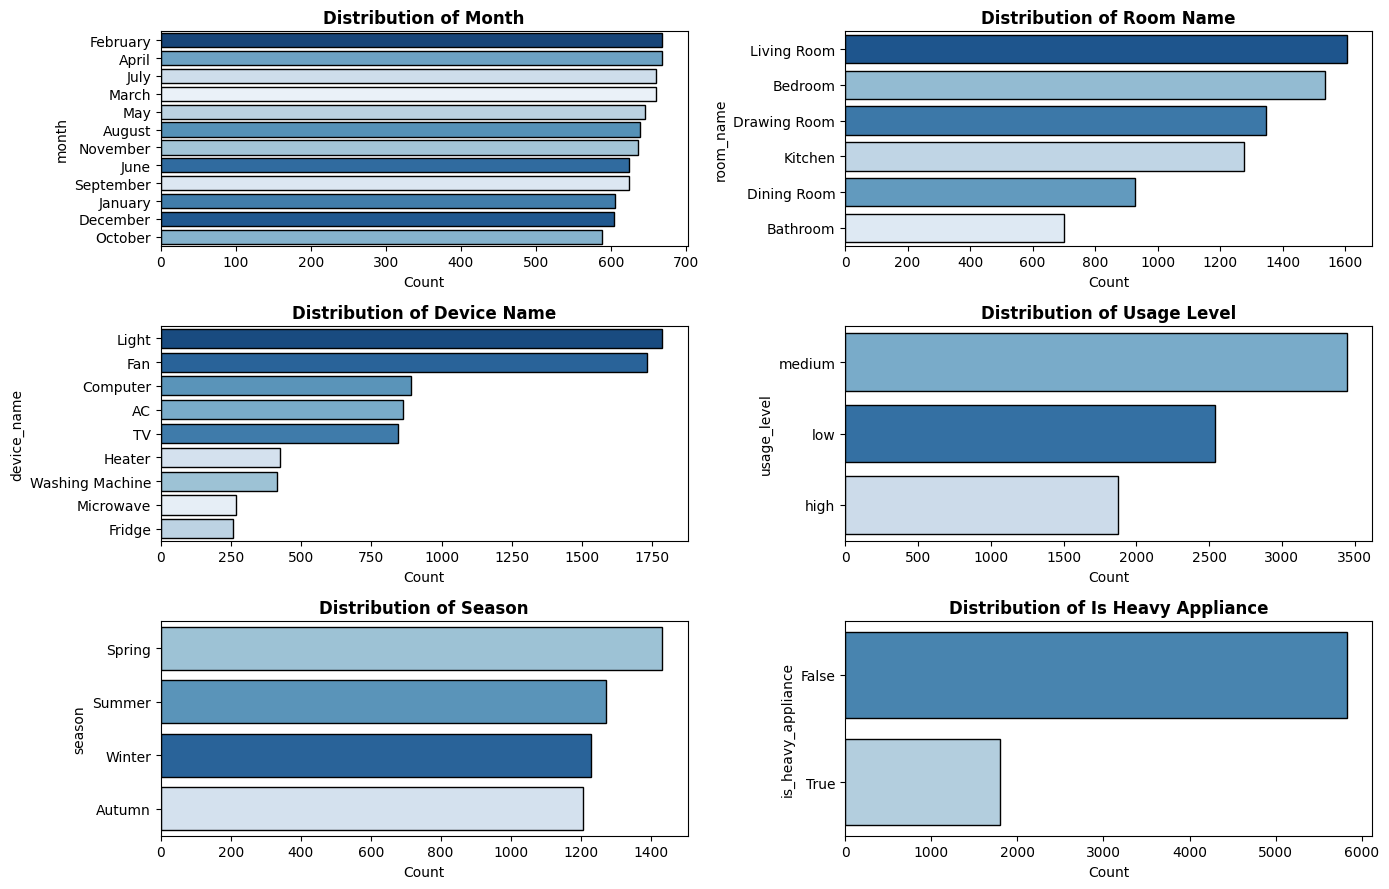

In [57]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
axes = axes.flatten()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue=col ,order=order , ax=axes[i], palette='Blues_r', edgecolor='black',legend=False)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

**Interpretation:** These subplots show how observations are distributed across the categorical features (room, device, season, usage level, month). Any strong class imbalance visible here is useful context when interpreting later relationships between these features and the target.


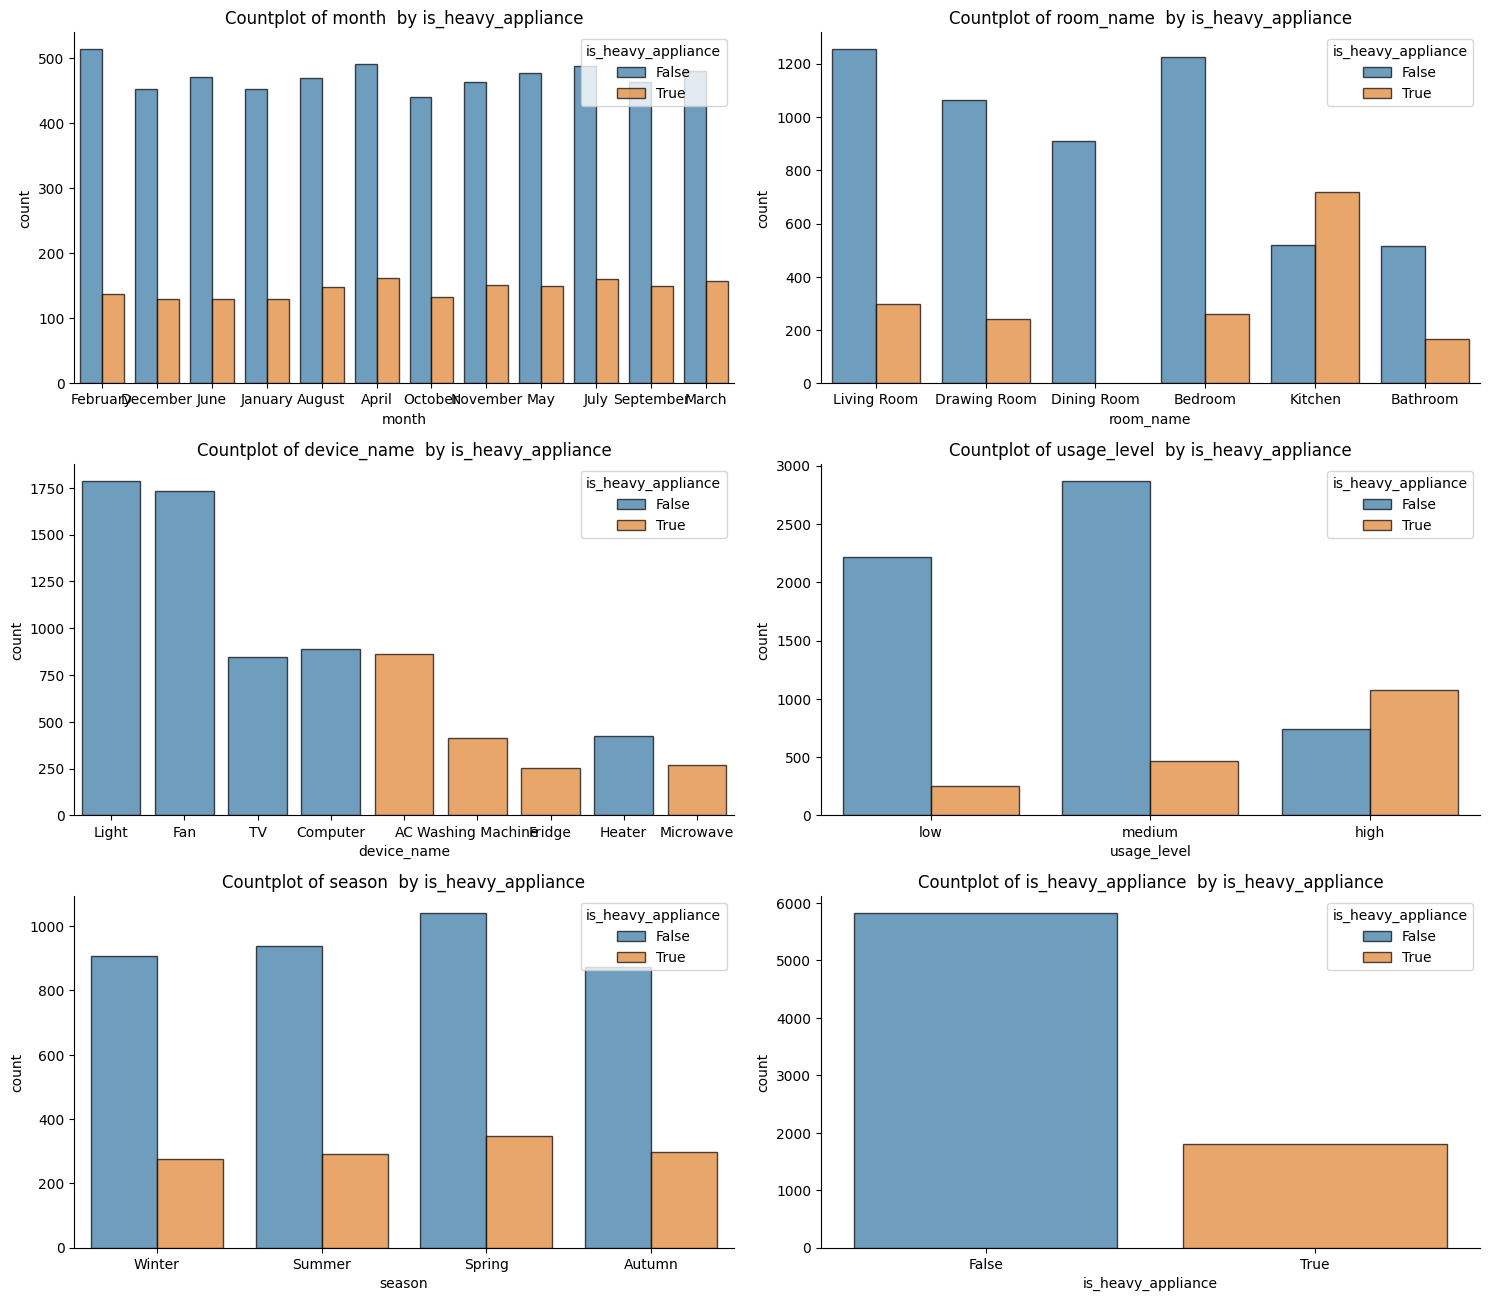

In [58]:
plt.figure(figsize=[15,17])

n=1
for f in cat_cols:
    plt.subplot(4,2,n)
    sns.countplot(x=f, hue='is_heavy_appliance', edgecolor="black", alpha=0.7, data=df)
    sns.despine()
    plt.title("Countplot of {}  by is_heavy_appliance".format(f))
    n=n+1
plt.tight_layout()
plt.show()

**Interpretation:** Breaking each categorical feature down by `is_heavy_appliance` highlights which categories (which devices, rooms, etc.) are more associated with heavy-load appliances — useful for understanding *why* certain records show high consumption.


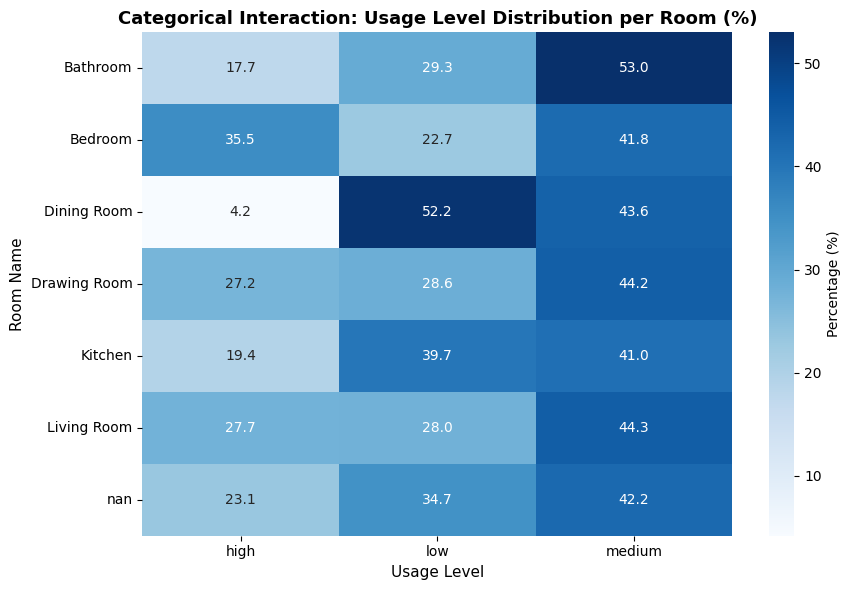

In [59]:
crosstab_room_usage = pd.crosstab(
    df['room_name'].astype(str).str.strip(),
    df['usage_level'].astype(str).str.strip(),
    normalize='index'
) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(crosstab_room_usage, annot=True, fmt=".1f", cmap='Blues', cbar_kws={'label': 'Percentage (%)'})

plt.title("Categorical Interaction: Usage Level Distribution per Room (%)", fontsize=13, fontweight='bold')
plt.xlabel("Usage Level", fontsize=11)
plt.ylabel("Room Name", fontsize=11)
plt.tight_layout()
plt.show()

display()

**Interpretation:** The normalized cross-tabulation of `room_name` vs. `usage_level` shows whether certain rooms are systematically associated with higher or lower usage intensity, independent of raw counts.


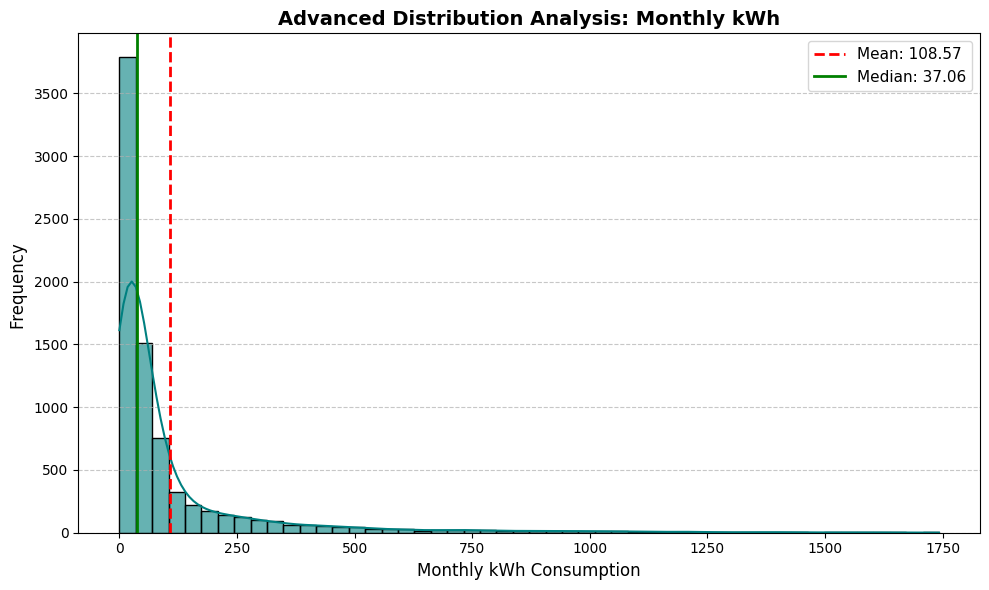

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='monthly_kwh',
    kde=True,
    bins=50,
    color='teal',
    edgecolor='black',
    alpha=0.6
)

mean_val = df['monthly_kwh'].mean()
median_val = df['monthly_kwh'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

plt.title("Advanced Distribution Analysis: Monthly kWh", fontsize=14, fontweight='bold')
plt.xlabel("Monthly kWh Consumption", fontsize=12)
plt.ylabel("Frequency ", fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Interpretation:** The distribution of the target variable `monthly_kwh` is right-skewed with a long tail toward higher consumption values, which is typical for energy-consumption data (most setups use a modest amount of power, with a smaller number of high-consumption outliers/appliances).


In [61]:

season_watts_gb = df.groupby('season')['watts'].agg(
    Count='count',
    Mean_Watts='mean',
    Median_Watts='median',
    Total_Watts='sum',
    Std_Dev='std'
).reset_index().sort_values(by='Mean_Watts', ascending=False)

print(" Groupby Summary: Watts Analysis Across Seasons")

display(season_watts_gb)


 Groupby Summary: Watts Analysis Across Seasons


,season,Count,Mean_Watts,Median_Watts,Total_Watts,Std_Dev
1,Spring,1340,433.280597,111.5,580596.0,718.866619
2,Summer,1200,421.963333,113.0,506356.0,698.685144
0,Autumn,1131,412.352785,106.0,466371.0,584.171200
3,Winter,1151,395.930495,101.0,455716.0,665.011316


/tmp/ipykernel_1168/2703537223.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1168/2703537223.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




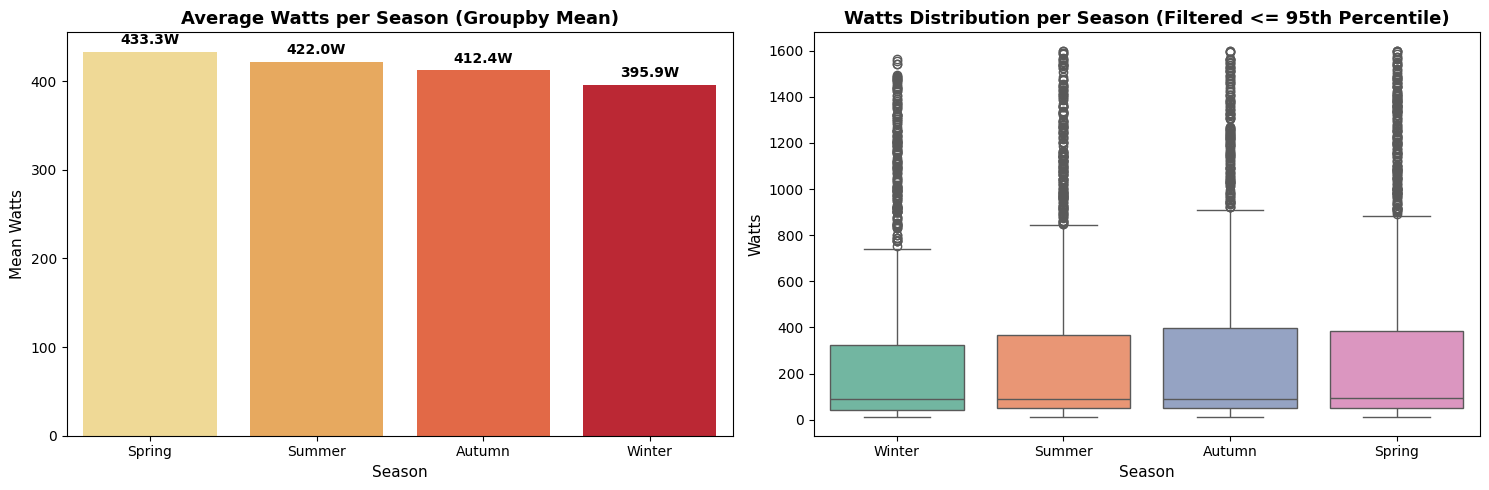

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1 = sns.barplot(data=season_watts_gb, x='season', y='Mean_Watts', ax=axes[0], palette='YlOrRd')
axes[0].set_title("Average Watts per Season (Groupby Mean)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Season", fontsize=11)
axes[0].set_ylabel("Mean Watts", fontsize=11)
for p in ax1.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax1.annotate(f'{height:.1f}W',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')
q_high = df['watts'].quantile(0.95)
sns.boxplot(data=df[df['watts'] <= q_high], x='season', y='watts', ax=axes[1], palette='Set2')
axes[1].set_title("Watts Distribution per Season (Filtered <= 95th Percentile)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Season", fontsize=11)
axes[1].set_ylabel("Watts", fontsize=11)

plt.tight_layout()
plt.show()

**Interpretation:** Aggregating `watts` by `season` shows whether power draw varies seasonally (e.g. higher average wattage in summer from cooling appliances, or winter from heaters). Differences here would motivate keeping `season`/`month` as predictive features rather than dropping them.


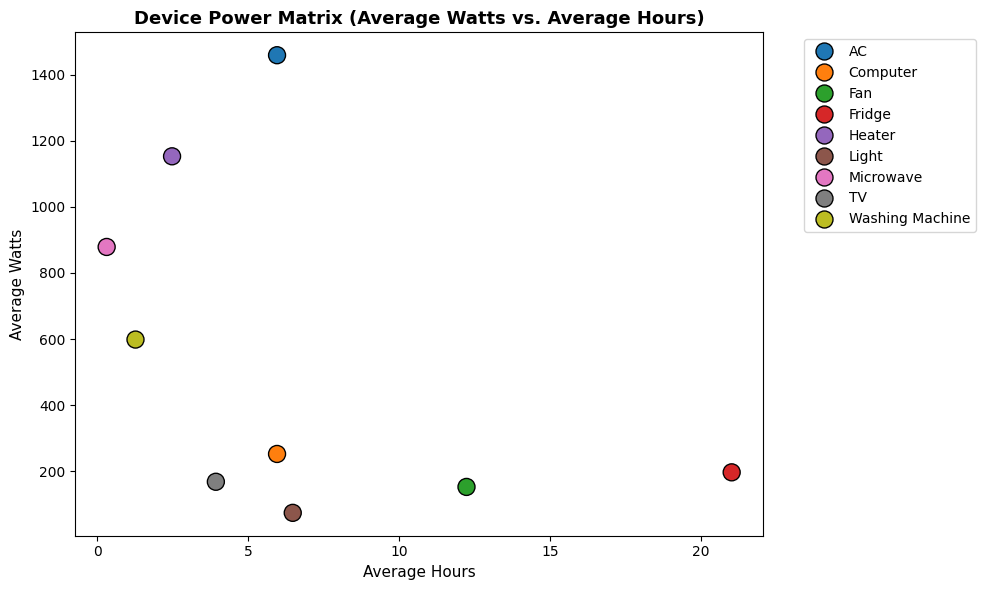

In [63]:
df_grouped = df.groupby('device_name')[['watts', 'hours']].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grouped,
    x='hours',
    y='watts',
    hue='device_name',
    s=150,
    edgecolor='black'
)

plt.title("Device Power Matrix (Average Watts vs. Average Hours)", fontsize=13, fontweight='bold')
plt.xlabel("Average Hours", fontsize=11)
plt.ylabel("Average Watts", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation:** Plotting average `hours` against average `watts` per device type separates devices into distinct usage profiles — e.g. low-wattage/long-duration devices (lights, fans) vs. high-wattage/short-duration devices (heaters, microwaves) — which helps explain how `monthly_kwh` is generated from the interaction of power and usage time.


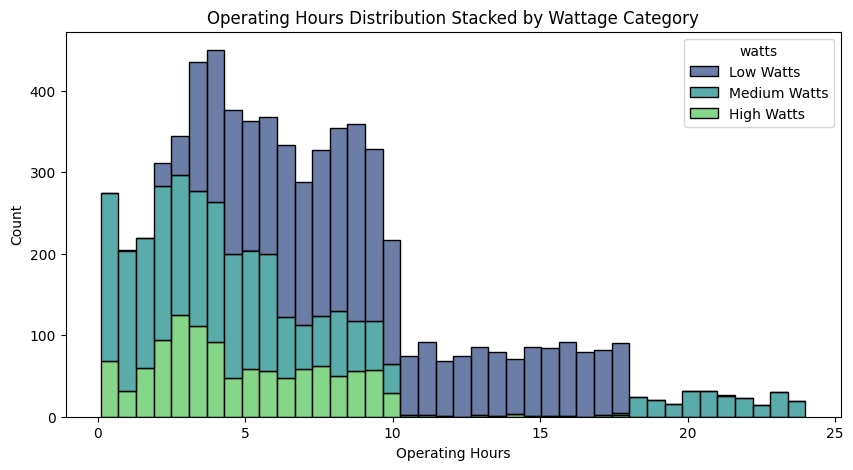

In [64]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='hours',
    hue=pd.cut(
        df['watts'],
        bins=[0, 100, 1000, df['watts'].max()],
        labels=['Low Watts', 'Medium Watts', 'High Watts']
    ),
    multiple='stack',
    palette='viridis'
)

plt.title("Operating Hours Distribution Stacked by Wattage Category")
plt.xlabel("Operating Hours")
plt.ylabel("Count")
plt.show()

**Interpretation:** Splitting the `hours` distribution by watt-range bins shows whether higher-power devices tend to be used for shorter or longer periods, which is directly relevant to predicting `monthly_kwh` (since kWh is a function of both watts and hours).


<Axes: xlabel='hours', ylabel='Count'>

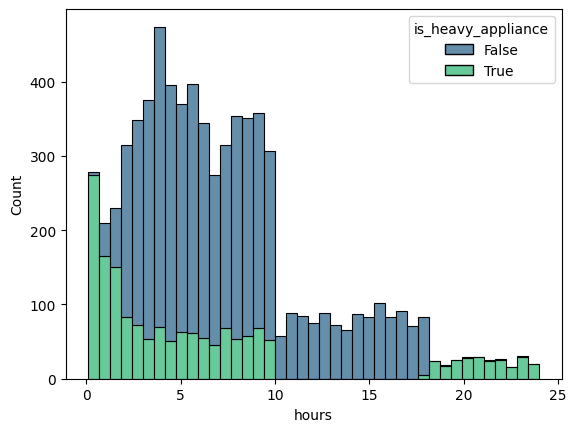

In [65]:
sns.histplot(data=df, x='hours', hue='is_heavy_appliance', multiple='stack', palette='viridis')

**Interpretation:** Comparing the `hours` distribution between heavy and non-heavy appliances shows whether heavy appliances also tend to be used for different lengths of time, adding another angle on the `is_heavy_appliance` flag's relationship with consumption.


<Axes: xlabel='hours', ylabel='watts'>

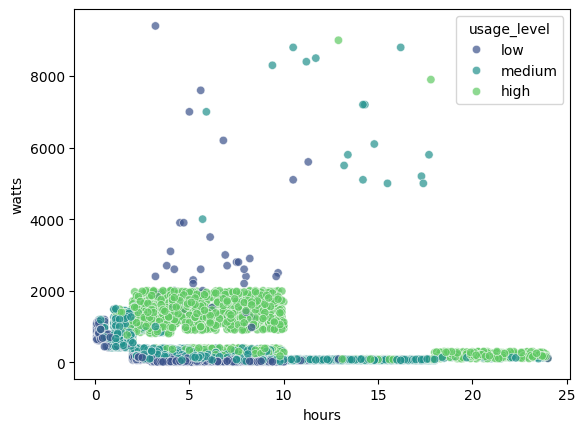

In [66]:
sns.scatterplot(data=df, x='hours', y='watts', hue='usage_level', palette='viridis', alpha=0.7)

**Interpretation:** Coloring the `hours` vs. `watts` scatter plot by `usage_level` checks whether the `usage_level` label (low/medium/high) lines up with the actual watts/hours combination — i.e. whether it is a consistent, informative summary of usage rather than an arbitrary label.


In [67]:
"""fig,ax=plt.subplots(3,5,figsize=(30,20))
ax=ax.flatten()
i=0
for col in df.columns:
    if(col!='target'):
        sns.histplot(data=df,x=col,kde=True,ax=ax[i])
        i+=1
plt.tight_layout()
"""

"fig,ax=plt.subplots(3,5,figsize=(30,20))\nax=ax.flatten()\ni=0\nfor col in df.columns:\n    if(col!='target'):\n        sns.histplot(data=df,x=col,kde=True,ax=ax[i])\n        i+=1\nplt.tight_layout()\n"

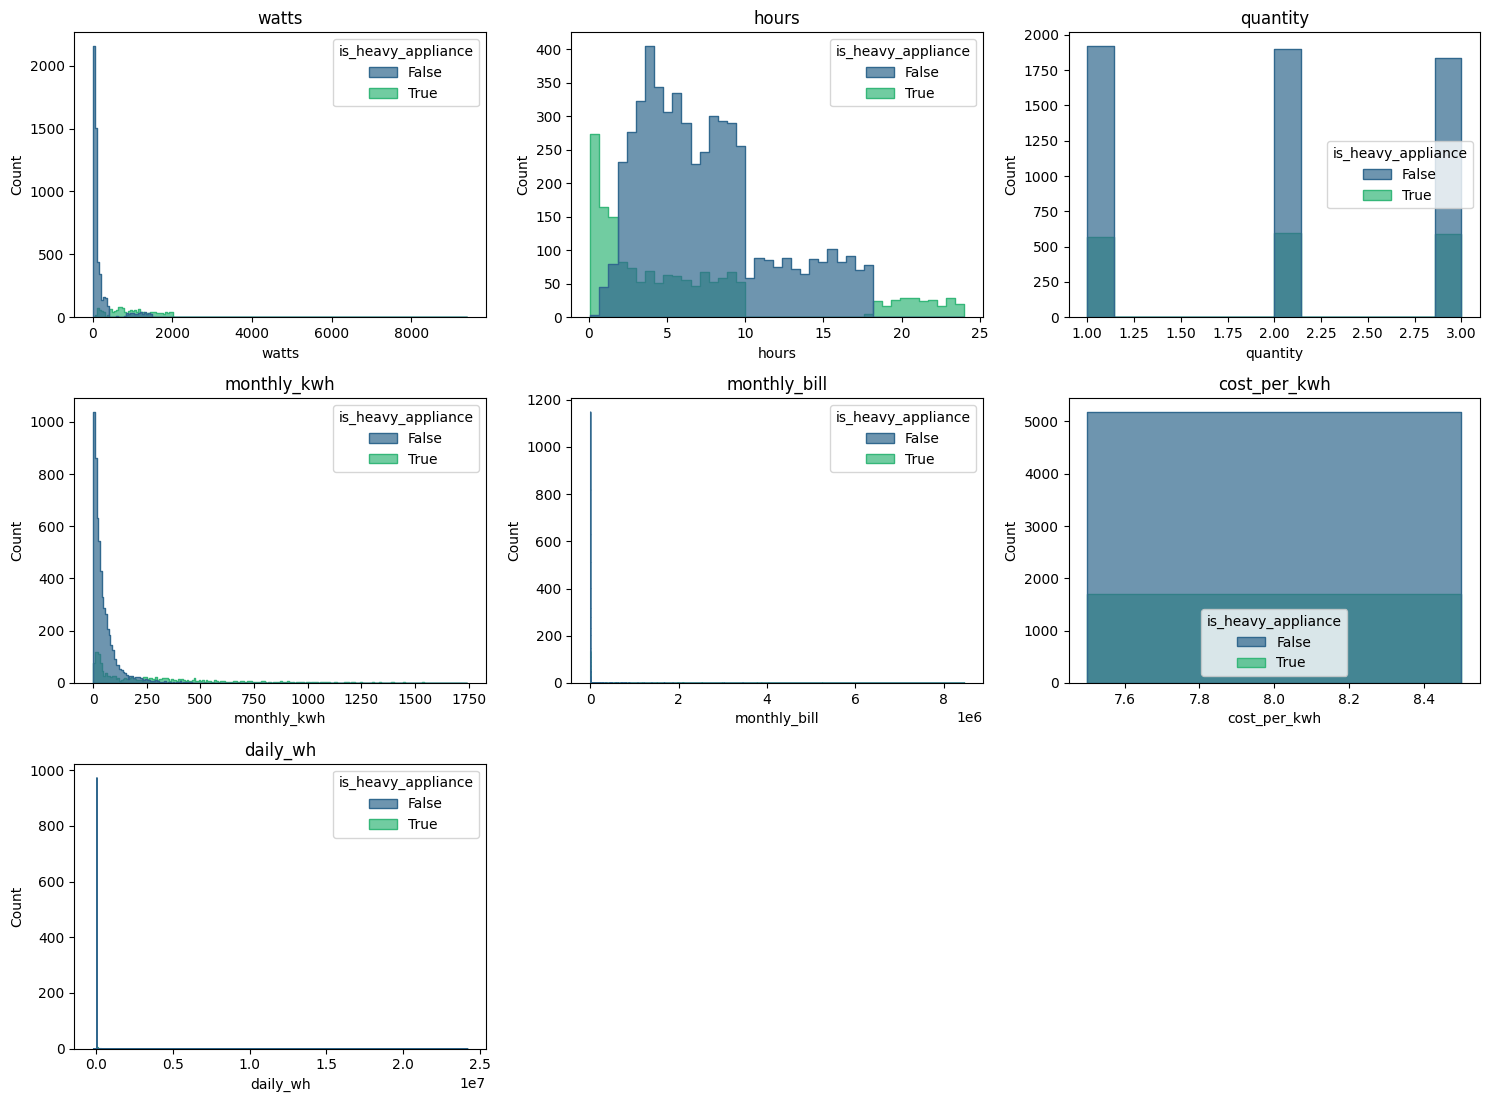

In [68]:
numerical_features = df.select_dtypes(include='number').drop(
    columns=['is_heavy_appliance_encoded'],
    errors='ignore'
).columns

plt.figure(figsize=(15, 18))

for i, col in enumerate(numerical_features):

    plt.subplot(5, 3, i + 1)

    sns.histplot(
        data=df,
        x=col,
        hue=df['is_heavy_appliance'],
        kde=False,
        element='step',
        palette='viridis',
        alpha=0.7,
        common_norm=False
    )

    plt.title(col)

plt.tight_layout()
plt.show()

,watts,hours,quantity,monthly_kwh,monthly_bill,cost_per_kwh,daily_wh
watts,1.000000,-0.228820,0.009866,0.527270,0.059915,NaN,0.060358
hours,-0.228820,1.000000,-0.011523,0.090547,0.013293,NaN,0.014858
quantity,0.009866,-0.011523,1.000000,0.225964,0.036137,NaN,0.041580
monthly_kwh,0.527270,0.090547,0.225964,1.000000,0.094020,NaN,0.065127
monthly_bill,0.059915,0.013293,0.036137,0.094020,1.000000,NaN,0.000797
cost_per_kwh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_wh,0.060358,0.014858,0.041580,0.065127,0.000797,NaN,1.000000


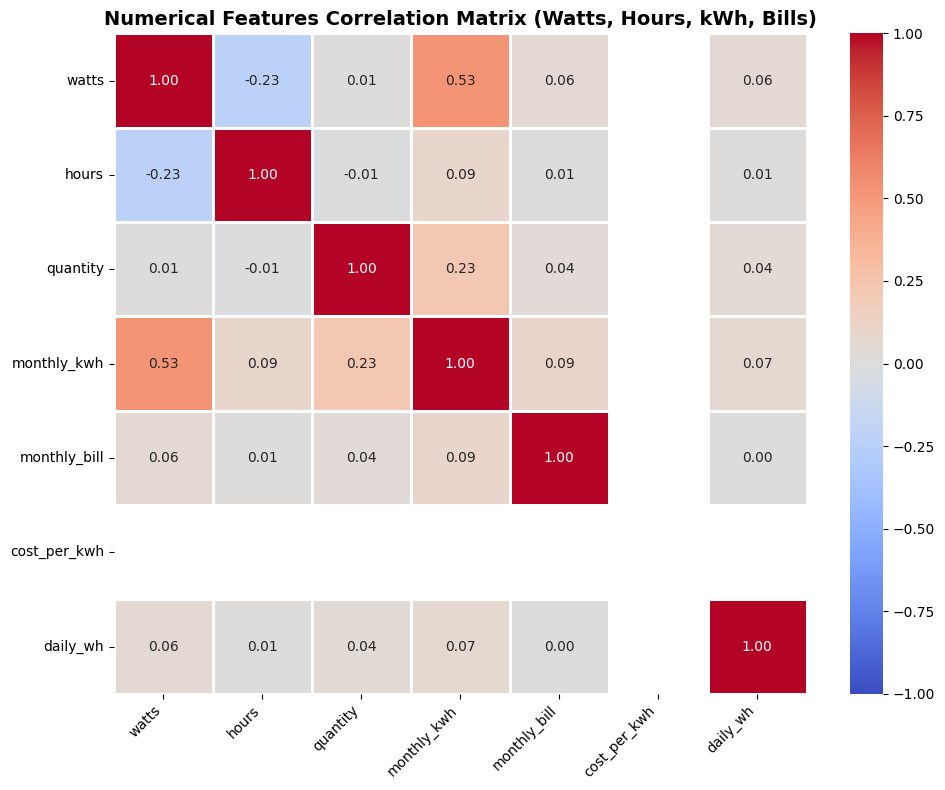

In [69]:

num_corr_matrix = df[numeric_cols].corr()
display(num_corr_matrix)

plt.figure(figsize=(10, 8))

sns.heatmap(
    num_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=1.0,
    cbar=True,
    vmin=-1, vmax=1
)

plt.title("Numerical Features Correlation Matrix (Watts, Hours, kWh, Bills)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


**Interpretation:** The correlation heatmap over numeric features highlights which raw numeric variables move together (potential redundancy / multicollinearity) and gives an early signal of which numeric features are most related to `monthly_kwh`, ahead of the more formal feature-selection step performed later in the pipeline.

This concludes the EDA stage. The dataset is next prepared for modeling.


## 6. Feature Engineering

The original methodology does not construct any new engineered features beyond the cleaning already applied above: the models are trained directly on the cleaned raw signals (`watts`, `hours`, `quantity`, `cost_per_kwh`, `month`, `room_name`, `device_name`, `usage_level`, `season`, `is_heavy_appliance`) and are left to learn interactions (e.g. watts × hours) themselves. `monthly_bill` and `daily_wh` are excluded entirely (see Section 7) because they are derived from the same underlying consumption as the target and would leak it.

To keep the deployment pipeline's *shape* identical to what is described in the project brief (`Raw Input → Cleaning → Feature Engineering → Imputation → ...`), a no-op `apply_feature_engineering` function is defined below. It exists purely as an explicit, documented interface point — if engineered features are added later, this is the single place to add them for both training and the Streamlit app.

In [70]:
def apply_feature_engineering(df_clean):
    return df_clean.copy()

In [71]:
df = apply_feature_engineering(df)

## 7. Define Features and Target

In [72]:
X = df.drop(columns=['monthly_kwh', 'monthly_bill', 'daily_wh'])
y = df['monthly_kwh']

**Data separation — Features (X) vs. Target (y):** `X` contains every column except the target `monthly_kwh` and two columns that are direct components/derivatives of it (`monthly_bill` and `daily_wh` are computed from the same underlying consumption, so keeping them in `X` would leak the target's information into the model). `y` is the value the model will learn to predict: `monthly_kwh`.

In [73]:
raw_input_columns = X.columns.tolist()
print('Raw input columns a Streamlit form must collect:', raw_input_columns)

Raw input columns a Streamlit form must collect: ['month', 'room_name', 'device_name', 'watts', 'hours', 'quantity', 'cost_per_kwh', 'usage_level', 'season', 'is_heavy_appliance']


**Deployment note:** `raw_input_columns` is exactly the set of fields a Streamlit form needs to collect from the user to build a valid one-row input DataFrame. It is saved as part of `feature_columns_config.pkl` in Section 13.

## 8. Train/Test Split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Data separation — Train vs. Test split:** The data is split 80% train / 20% test with a fixed `random_state` for reproducibility. The training set is used to fit every preprocessing step and every model; the test set is held out purely for unbiased evaluation and is never used to fit anything.

## 9. Preprocessing

Every transformer below follows the same pattern: **fit on `X_train` only, transform `X_train`, then transform `X_test` using the already-fitted transformer.** Nothing here is fit on the full dataset or on `X_test`, which prevents data leakage. Each fitted object is saved immediately with `joblib` so it can be reloaded and reused, unchanged, at inference time.

In [75]:
numeric_impute_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_impute_cols] = num_imputer.fit_transform(X_train[numeric_impute_cols])
X_test[numeric_impute_cols] = num_imputer.transform(X_test[numeric_impute_cols])

### Imputation — Numeric Features

Remaining gaps in numeric columns (`watts`, `hours`, `quantity`, `cost_per_kwh`, etc.) are filled using the **median** of each column (robust to the outliers/skew seen during EDA), fit on `X_train` only and then applied to `X_test`. The fitted imputer is saved to disk so the exact same fill values can be reused on new data at inference time.

In [76]:
joblib.dump(num_imputer, "numeric_imputer.pkl")

['numeric_imputer.pkl']

In [77]:
categorical_impute_cols = X_train.select_dtypes(include=['object']).columns.tolist()
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_impute_cols] = cat_imputer.fit_transform(X_train[categorical_impute_cols])
X_test[categorical_impute_cols] = cat_imputer.transform(X_test[categorical_impute_cols])

### Imputation — Categorical Features

Remaining gaps in categorical columns (`month`, `room_name`, `device_name`, `usage_level`, `season`) are filled with the **most frequent category** of each column, again fit on `X_train` only. The fitted imputer is saved for reuse.

In [78]:
joblib.dump(cat_imputer, "categorical_imputer.pkl")

['categorical_imputer.pkl']

In [79]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6288 entries, 432 to 7270
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               6288 non-null   object 
 1   room_name           6288 non-null   object 
 2   device_name         6288 non-null   object 
 3   watts               6288 non-null   float64
 4   hours               6288 non-null   float64
 5   quantity            6288 non-null   float64
 6   cost_per_kwh        6288 non-null   float64
 7   usage_level         6288 non-null   object 
 8   season              6288 non-null   object 
 9   is_heavy_appliance  6288 non-null   object 
dtypes: float64(4), object(6)
memory usage: 540.4+ KB


**Interpretation:** `X_train.info()` now shows zero missing values across all columns — imputation for both numeric and categorical features is complete.

### 9.1 Encoding categorical features

Machine-learning models need numeric input, so every remaining categorical/text column is converted to a numeric representation. Each encoding below is followed by a `joblib` dump of the fitted encoder/mapping so it can be applied consistently to new, unseen data later.

In [80]:
month_to_num = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
X_train['month'] = X_train['month'].map(month_to_num)
X_test['month'] = X_test['month'].map(month_to_num)


**Encoding `month` (ordinal mapping):** Since months have a natural cyclical order, `month` is mapped to integers 1–12 using an explicit dictionary rather than one-hot encoding, keeping the feature compact.

In [81]:
joblib.dump(month_to_num, "month_encoder.pkl")

['month_encoder.pkl']

In [82]:
ohe_cols = ['room_name', 'device_name', 'season']
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
)
train_encoded = ohe.fit_transform(X_train[ohe_cols])
test_encoded = ohe.transform(X_test[ohe_cols])

In [83]:
encoded_cols = ohe.get_feature_names_out(ohe_cols)
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=X_train.index
)
test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=X_test.index
)
X_train = pd.concat(
    [X_train.drop(columns=ohe_cols), train_encoded],
    axis=1
)
X_test = pd.concat(
    [X_test.drop(columns=ohe_cols), test_encoded],
    axis=1
)

**Encoding `room_name`, `device_name`, `season` (One-Hot Encoding):** These columns have no natural order, so `OneHotEncoder` is used to create one binary column per category. `handle_unknown='ignore'` makes the encoder safe to reuse on new data that might contain unseen categories. The fitted encoder is saved so the exact same columns/mapping are reproduced at inference time.

In [84]:
joblib.dump(ohe, "onehot_encoder.pkl")

['onehot_encoder.pkl']

In [85]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6288 entries, 432 to 7270
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   month                        6288 non-null   int64  
 1   watts                        6288 non-null   float64
 2   hours                        6288 non-null   float64
 3   quantity                     6288 non-null   float64
 4   cost_per_kwh                 6288 non-null   float64
 5   usage_level                  6288 non-null   object 
 6   is_heavy_appliance           6288 non-null   object 
 7   room_name_Bathroom           6288 non-null   float64
 8   room_name_Bedroom            6288 non-null   float64
 9   room_name_Dining Room        6288 non-null   float64
 10  room_name_Drawing Room       6288 non-null   float64
 11  room_name_Kitchen            6288 non-null   float64
 12  room_name_Living Room        6288 non-null   float64
 13  device_name_AC       

**Interpretation:** `X_train.info()` now shows the one-hot encoded columns (`room_name_...`, `device_name_...`, `season_...`) in place of the original text columns.

In [86]:
X_train['usage_level'].value_counts()

,count
usage_level,
medium,2767
low,2026
high,1495


In [87]:
usage_map = {'low': 0, 'medium': 1, 'high': 2}
X_train['usage_level'] = X_train['usage_level'].map(usage_map)
X_test['usage_level'] = X_test['usage_level'].map(usage_map)

**Encoding `usage_level` (ordinal mapping):** `usage_level` has a natural order (`low < medium < high`), so it is mapped to integers 0/1/2 rather than one-hot encoded, preserving that ordering for the model.

In [88]:
joblib.dump(usage_map, "usage_level_encoder.pkl")

['usage_level_encoder.pkl']

In [89]:
print(X_train['is_heavy_appliance'].unique())

[True False]


In [90]:
heavy_map = {
    False: 0,
    True: 1
}

X_train['is_heavy_appliance'] = X_train['is_heavy_appliance'].map(heavy_map)
X_test['is_heavy_appliance'] = X_test['is_heavy_appliance'].map(heavy_map)

**Encoding `is_heavy_appliance` (binary mapping):** This boolean flag is mapped to 0/1 so it can be used directly as a numeric feature.

In [91]:
joblib.dump(heavy_map, "is_heavy_appliance_encoder.pkl")

['is_heavy_appliance_encoder.pkl']

In [92]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6288 entries, 432 to 7270
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   month                        6288 non-null   int64  
 1   watts                        6288 non-null   float64
 2   hours                        6288 non-null   float64
 3   quantity                     6288 non-null   float64
 4   cost_per_kwh                 6288 non-null   float64
 5   usage_level                  6288 non-null   int64  
 6   is_heavy_appliance           6288 non-null   int64  
 7   room_name_Bathroom           6288 non-null   float64
 8   room_name_Bedroom            6288 non-null   float64
 9   room_name_Dining Room        6288 non-null   float64
 10  room_name_Drawing Room       6288 non-null   float64
 11  room_name_Kitchen            6288 non-null   float64
 12  room_name_Living Room        6288 non-null   float64
 13  device_name_AC       

**Interpretation:** All features in `X_train` / `X_test` are now fully numeric — encoding is complete. Before scaling, a quick consistency check confirms both splits ended up with identical columns in identical order (a mismatch here would silently corrupt scaling/model input).

In [93]:
assert list(X_train.columns) == list(X_test.columns), "X_train/X_test columns diverged after encoding!"
print('OK: X_train and X_test have identical, aligned columns after encoding:', X_train.shape[1], 'columns')

OK: X_train and X_test have identical, aligned columns after encoding: 26 columns


In [94]:
scaled_columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = RobustScaler()
X_train[scaled_columns] = scaler.fit_transform(X_train[scaled_columns])
X_test[scaled_columns] = scaler.transform(X_test[scaled_columns])

### 9.2 Scaling numeric features

`RobustScaler` (which uses the median and interquartile range) is applied to the numeric columns — which, at this point, is effectively every column since encoding made everything numeric. It is chosen over `StandardScaler`/`MinMaxScaler` specifically because the EDA showed skewed distributions and outliers in features like `watts`, `hours`, and `cost_per_kwh` — the median/IQR basis makes the scaling less sensitive to those extreme values. The scaler is fit on `X_train` only and then applied to `X_test`, and the fitted object is saved for reuse at inference time. `scaled_columns` (the exact column list/order the scaler expects) is also saved, since a new inference row must present its columns in this same order before calling `scaler.transform`.

In [95]:
joblib.dump(scaler, "robust_scaler.pkl")

['robust_scaler.pkl']

## 10. Feature Selection

Several complementary feature-selection methods are compared below (Mutual Information, `SelectKBest` with F-regression, Recursive Feature Elimination with a Random Forest, and Random Forest feature importances), run on the fully preprocessed (imputed, encoded, scaled) `X_train` / `X_test`. A feature is kept in the final set if at least 2 of the 4 methods agree on it.

                Feature  Mutual Information
0           usage_level            1.065064
1                 watts            0.691648
2                 hours            0.340018
3     device_name_Light            0.262381
4        device_name_AC            0.215697
5    is_heavy_appliance            0.151071
6       device_name_Fan            0.141699
7              quantity            0.097032
8    device_name_Heater            0.059510
9  device_name_Computer            0.057244


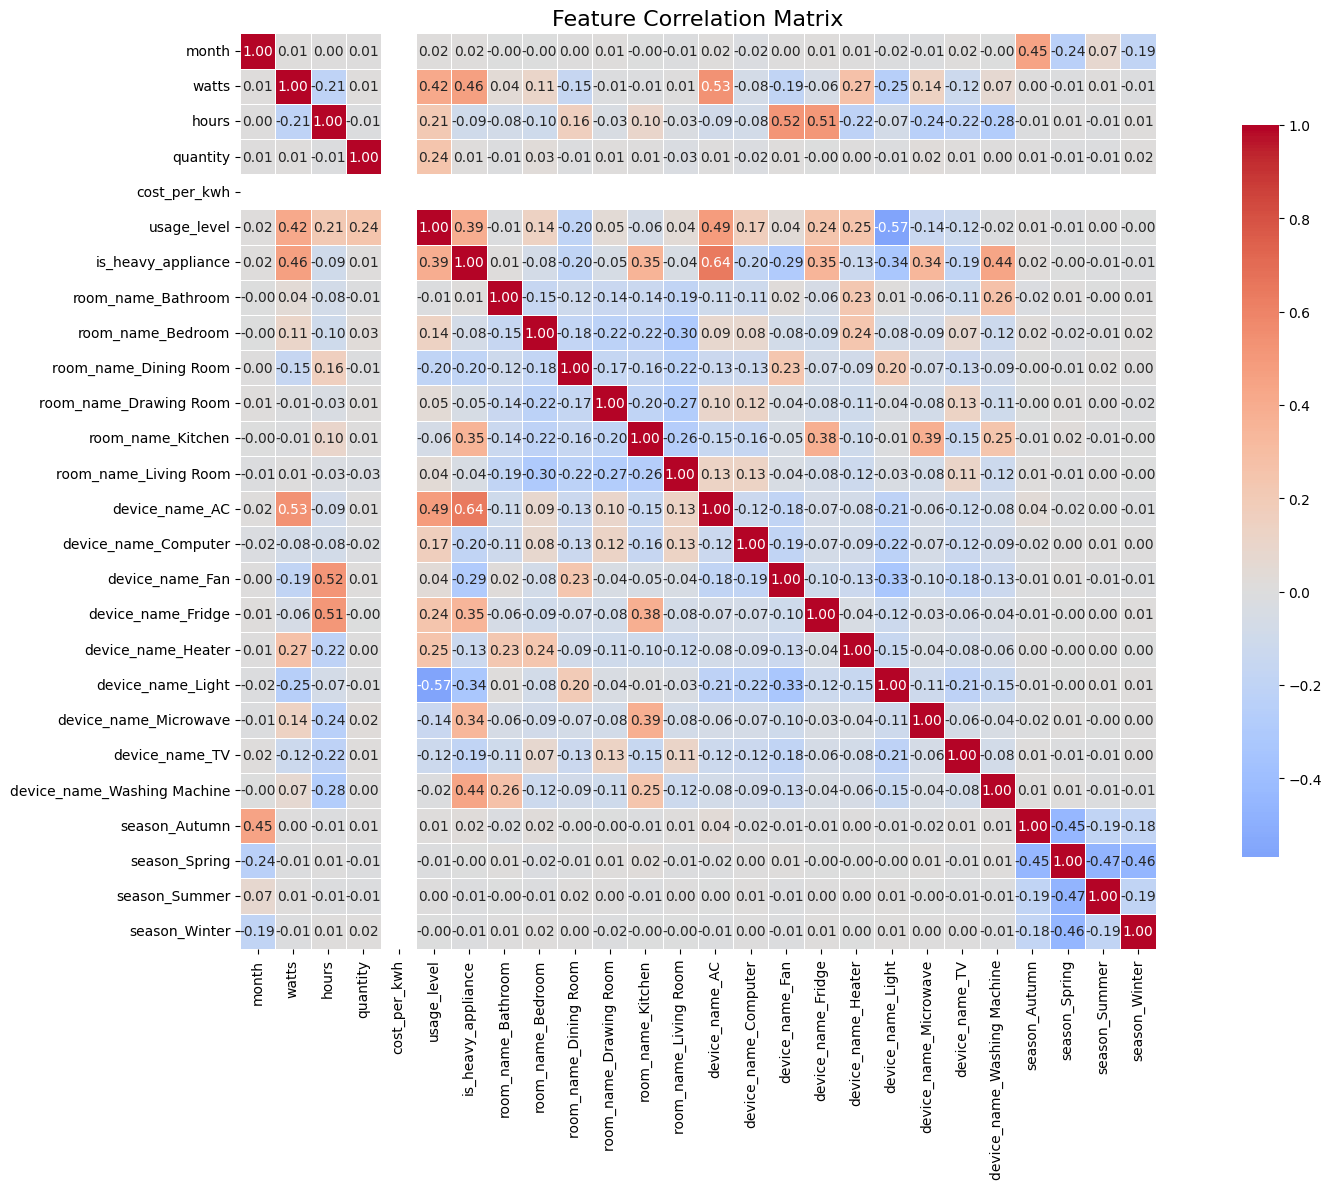

/tmp/ipykernel_1168/3614781316.py:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




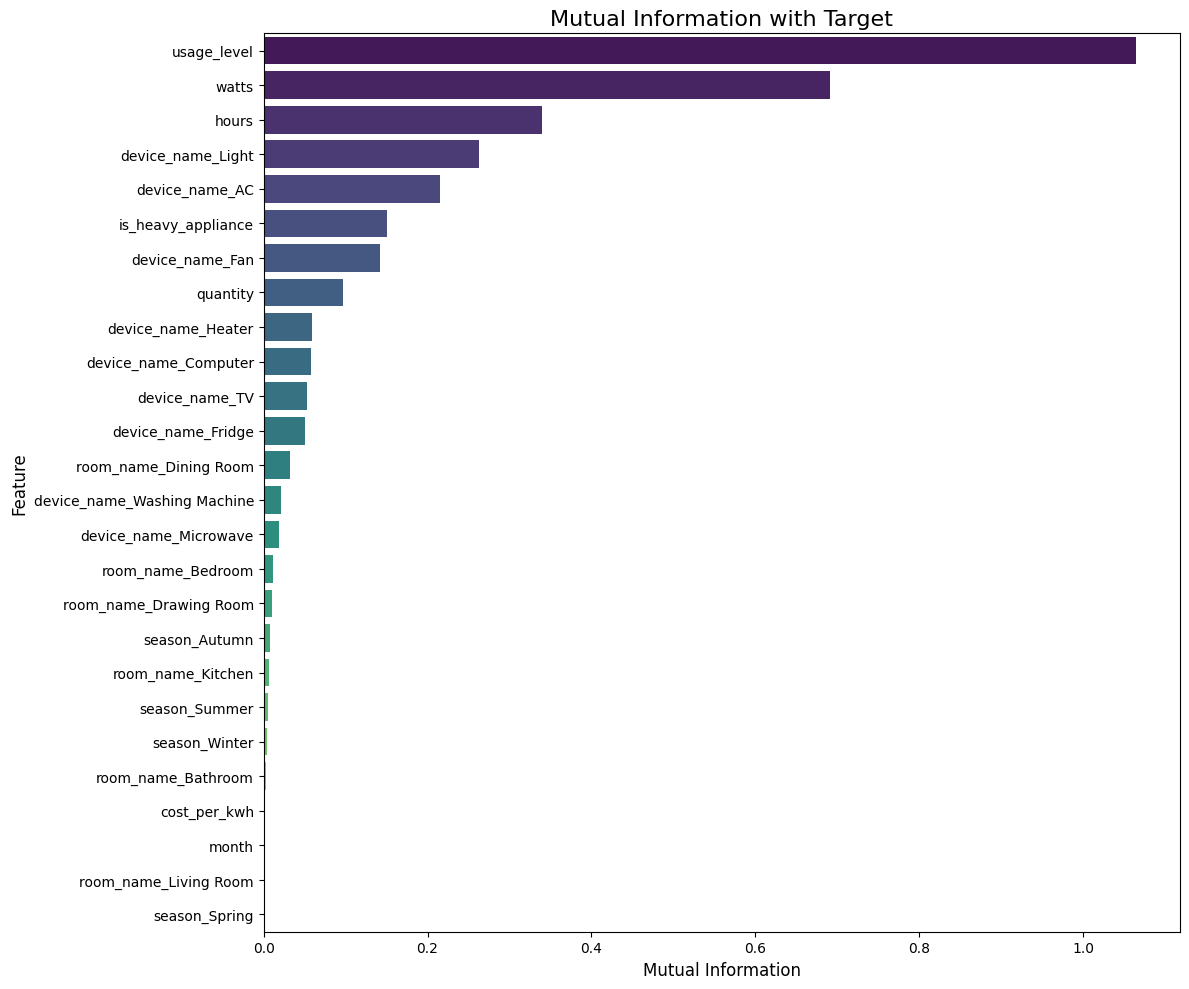

Low MI features:
['room_name_Drawing Room', 'season_Autumn', 'room_name_Kitchen', 'season_Summer', 'season_Winter', 'room_name_Bathroom', 'cost_per_kwh', 'month', 'room_name_Living Room', 'season_Spring']


In [96]:

X = X_train.copy()
y = y_train.copy()

mi = mutual_info_regression(
    X,
    y,
    random_state=1
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information': mi
}).sort_values(
    by='Mutual Information',
    ascending=False
).reset_index(drop=True)

print(mi_df.head(10))


# Correlation Matrix
plt.figure(figsize=(18, 12))

corr_matrix = X.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 10))

sns.barplot(
    data=mi_df,
    x='Mutual Information',
    y='Feature',
    palette='viridis'
)

plt.title('Mutual Information with Target', fontsize=16)
plt.xlabel('Mutual Information', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()


threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")


low_mi_threshold = 0.01

low_mi_features = mi_df[
    mi_df['Mutual Information'] < low_mi_threshold
]['Feature'].tolist()

print("Low MI features:")
print(low_mi_features)

**Interpretation:** Mutual Information (which can capture non-linear relationships, unlike Pearson correlation) ranks features by how much information they provide about `monthly_kwh`. The correlation heatmap over the now fully-numeric feature set also flags any pairs of engineered/encoded features that are highly correlated with each other (redundant information), and features with very low mutual information are flagged as candidates for removal.


In [97]:
corr_df = X_train.copy()
corr_df['monthly_kwh'] = y_train

corr_cols = (
    corr_df.corr(numeric_only=True)['monthly_kwh']
    .drop('monthly_kwh')
    .loc[lambda x: (x > 0.1) | (x < -0.1)]
    .index
)

corr_cols

Index(['watts', 'quantity', 'usage_level', 'is_heavy_appliance',
       'room_name_Bedroom', 'room_name_Dining Room', 'device_name_AC',
       'device_name_Fan', 'device_name_Fridge', 'device_name_Light',
       'device_name_TV'],
      dtype='object')

**Interpretation:** As a complementary, linear view, features whose Pearson correlation with `monthly_kwh` exceeds ±0.1 are listed — a simple sanity check against the mutual-information ranking above.


In [98]:
selected_features = mi_df[mi_df['Mutual Information'] > 0.01]['Feature'].tolist()
X_train_fs = X_train[selected_features]
X_test_fs  = X_test[selected_features]
print(f"Selected {len(selected_features)} features out of {X_train.shape[1]}")

Selected 16 features out of 26


## 6. Feature Selection

Several complementary feature-selection methods are compared below (Mutual Information, `SelectKBest` with F-regression, Recursive Feature Elimination with a Random Forest, and Random Forest feature importances). Here, features with Mutual Information above `0.01` are kept as a first working feature set (`X_train_fs` / `X_test_fs`).


In [99]:
target_corr = df.corr(numeric_only=True)['monthly_kwh'].sort_values(
    ascending=False
)
print(target_corr)

monthly_kwh     1.000000
watts           0.527270
quantity        0.225964
monthly_bill    0.094020
hours           0.090547
daily_wh        0.065127
cost_per_kwh         NaN
Name: monthly_kwh, dtype: float64


**Interpretation:** This full correlation ranking (computed on the cleaned `df` before splitting/encoding) gives a quick, human-readable overview of which raw numeric columns move most strongly with `monthly_kwh` — useful context, though it does not include the encoded categorical features.


In [100]:
k_best = SelectKBest(score_func=f_regression, k=15)
X_train_kbest = k_best.fit_transform(X_train, y_train)
X_test_kbest = k_best.transform(X_test)
kbest_features = X_train.columns[k_best.get_support()]
print(f"SelectKBest selected {len(kbest_features)} features:")
print(kbest_features.tolist())

SelectKBest selected 15 features:
['watts', 'hours', 'quantity', 'usage_level', 'is_heavy_appliance', 'room_name_Bedroom', 'room_name_Dining Room', 'room_name_Drawing Room', 'device_name_AC', 'device_name_Fan', 'device_name_Fridge', 'device_name_Heater', 'device_name_Light', 'device_name_Microwave', 'device_name_TV']


**Interpretation:** `SelectKBest` with an F-regression score picks the 15 features with the strongest **linear** relationship to the target — a useful cross-check against the (non-linear-aware) Mutual Information ranking above.


In [101]:
rfe_estimator = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=15)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)
rfe_features = X_train.columns[rfe.get_support()]
print(f"RFE selected {len(rfe_features)} features:")
print(rfe_features.tolist())

RFE selected 15 features:
['month', 'watts', 'hours', 'quantity', 'usage_level', 'room_name_Bedroom', 'room_name_Drawing Room', 'room_name_Living Room', 'device_name_AC', 'device_name_Computer', 'device_name_Fridge', 'device_name_Heater', 'device_name_Light', 'season_Spring', 'season_Summer']


**Interpretation:** Recursive Feature Elimination (RFE), using a Random Forest as the underlying estimator, iteratively removes the least useful features and keeps the top 15 — this captures feature usefulness from a tree-based, non-linear perspective.


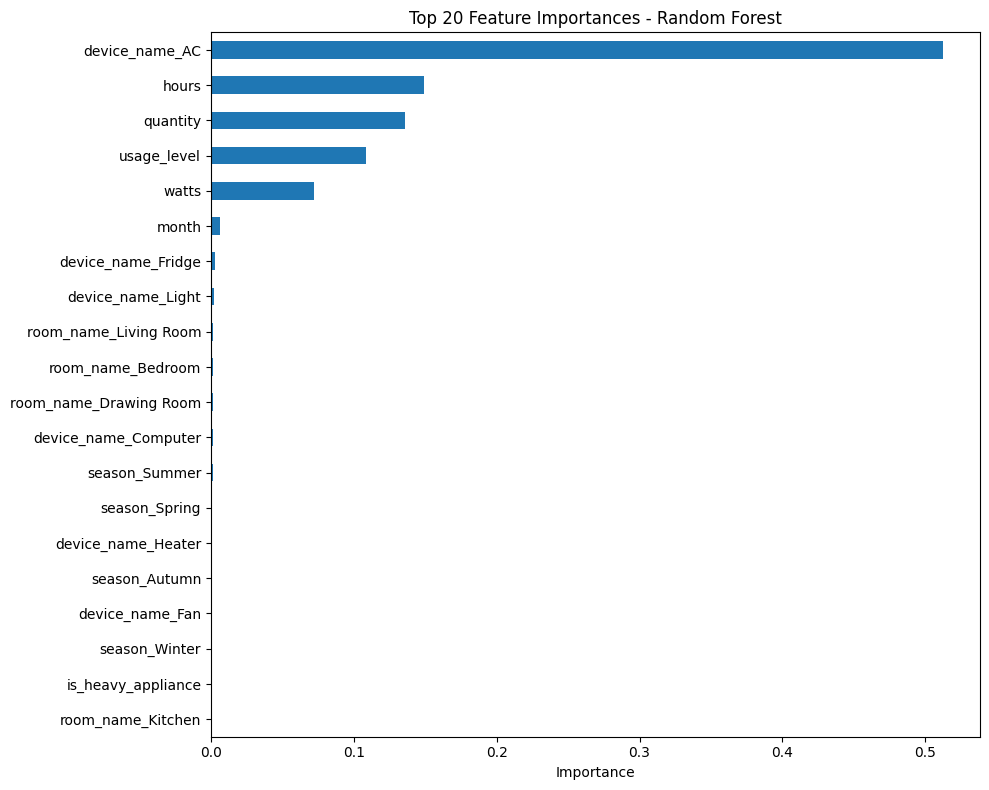

Top features by Random Forest importance:
['device_name_AC', 'hours', 'quantity', 'usage_level', 'watts', 'month', 'device_name_Fridge', 'device_name_Light', 'room_name_Living Room', 'room_name_Bedroom', 'room_name_Drawing Room', 'device_name_Computer', 'season_Summer', 'season_Spring', 'device_name_Heater']


In [102]:
rf_importance = RandomForestRegressor(n_estimators=200, random_state=42)
rf_importance.fit(X_train, y_train)
importances = pd.Series(rf_importance.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
rf_top_features = importances.head(15).index.tolist()
print("Top features by Random Forest importance:")
print(rf_top_features)

**Interpretation:** Random Forest feature importances give a fourth, independent view of feature relevance, based on how much each feature reduces impurity across the trees.


In [103]:
feature_sets = {
    "Mutual Information": list(selected_features),
    "SelectKBest (f_regression)": kbest_features.tolist(),
    "RFE (Random Forest)": rfe_features.tolist(),
    "Random Forest Importance": rf_top_features
}
for name, feats in feature_sets.items():
    print(f"{name}: {len(feats)} features")
common_features = (
    set(selected_features)
    & set(kbest_features)
    & set(rfe_features)
    & set(rf_top_features)
)
print(f"\nFeatures agreed on by all 4 methods ({len(common_features)}):")
print(common_features)

Mutual Information: 16 features
SelectKBest (f_regression): 15 features
RFE (Random Forest): 15 features
Random Forest Importance: 15 features

Features agreed on by all 4 methods (9):
{'watts', 'quantity', 'room_name_Bedroom', 'device_name_Fridge', 'usage_level', 'device_name_Heater', 'hours', 'device_name_Light', 'device_name_AC'}


**Interpretation:** Comparing the four feature-selection methods side by side, and looking at the features every method agrees on, builds confidence that those features are genuinely important rather than an artifact of one particular method.


In [104]:
all_selected = (
    list(selected_features)
    + kbest_features.tolist()
    + rfe_features.tolist()
    + rf_top_features
)
vote_counts = Counter(all_selected)
final_selected_features = [feat for feat, count in vote_counts.items() if count >= 2]
print(f"Final selected features (voted by >= 2 out of 4 methods): {len(final_selected_features)}")
print(final_selected_features)
X_train_fs = X_train[final_selected_features]
X_test_fs = X_test[final_selected_features]
print(f"\nX_train_fs shape: {X_train_fs.shape}")
print(f"X_test_fs shape:  {X_test_fs.shape}")

Final selected features (voted by >= 2 out of 4 methods): 20
['usage_level', 'watts', 'hours', 'device_name_Light', 'device_name_AC', 'is_heavy_appliance', 'device_name_Fan', 'quantity', 'device_name_Heater', 'device_name_Computer', 'device_name_TV', 'device_name_Fridge', 'room_name_Dining Room', 'device_name_Microwave', 'room_name_Bedroom', 'room_name_Drawing Room', 'month', 'room_name_Living Room', 'season_Spring', 'season_Summer']

X_train_fs shape: (6288, 20)
X_test_fs shape:  (1573, 20)


**Interpretation:** A simple voting scheme keeps any feature selected by at least 2 of the 4 methods, producing the final feature set (`X_train_fs` / `X_test_fs`) used for model training below — a balance between being selective and not discarding a feature that only one method happened to miss.

## 7. Model Training, Comparison, Tuning & Stacking


In [105]:
joblib.dump(final_selected_features, "selected_features.pkl")
print(f"Saved {len(final_selected_features)} selected features to selected_features.pkl")

Saved 20 selected features to selected_features.pkl


### 10.1 Feature-consistency validation

Before moving on to modeling, a few checks confirm there is no mismatch waiting to surface later (item #6 of the deployment brief): the selected features actually exist in `X_train_fs`/`X_test_fs`, in the same order, and that order is exactly what gets saved and later reloaded for Streamlit inference.

In [106]:
assert list(X_train_fs.columns) == final_selected_features, "X_train_fs column order does not match final_selected_features!"
assert list(X_test_fs.columns) == final_selected_features, "X_test_fs column order does not match final_selected_features!"
assert set(final_selected_features).issubset(set(scaled_columns)), "A selected feature is missing from the scaled column set!"
print('OK: selected feature order is consistent across X_train_fs, X_test_fs, and the saved artifact.')

OK: selected feature order is consistent across X_train_fs, X_test_fs, and the saved artifact.


## 11. Model Training

A range of regression models — linear (Linear Regression, Ridge, Lasso), instance-based (KNN), tree-based (Decision Tree, Random Forest, Extra Trees), and boosting (Gradient Boosting/XGBoost/etc.) — are trained and compared under the same conditions, then the top performers are cross-validated, tuned, and combined via stacking.

In [107]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=1),
    "Lasso": Lasso(random_state=1),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=1),
    "AdaBoost": AdaBoostRegressor(random_state=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=1),
    "XGBoost": XGBRegressor(random_state=1),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=1),
    "LightGBM": LGBMRegressor(random_state=1)
}

A range of regression models — linear (Linear Regression, Ridge, Lasso), instance-based (KNN), tree-based (Decision Tree, Random Forest, Extra Trees), and boosting (Gradient Boosting/XGBoost/etc., if included) — are defined here so they can all be trained and compared under the same conditions.


  0%|          | 0/13 [00:00<?, ?it/s]

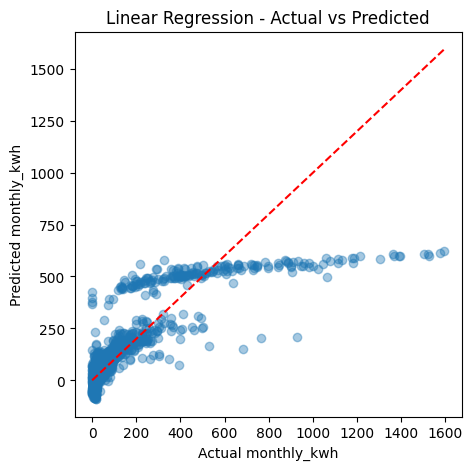

  8%|▊         | 1/13 [00:00<00:04,  2.82it/s]

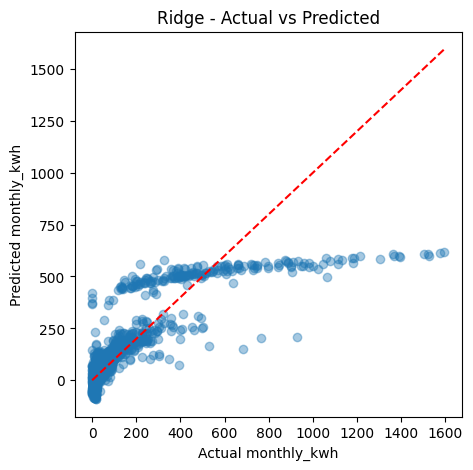

 15%|█▌        | 2/13 [00:00<00:02,  3.79it/s]

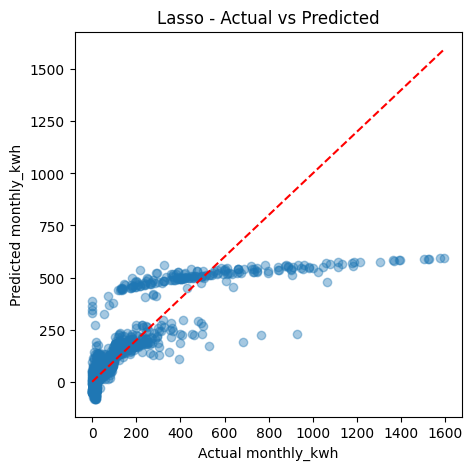

 23%|██▎       | 3/13 [00:00<00:02,  4.48it/s]

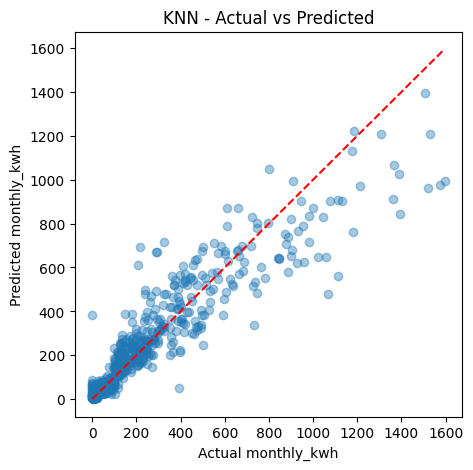

 31%|███       | 4/13 [00:01<00:03,  2.95it/s]

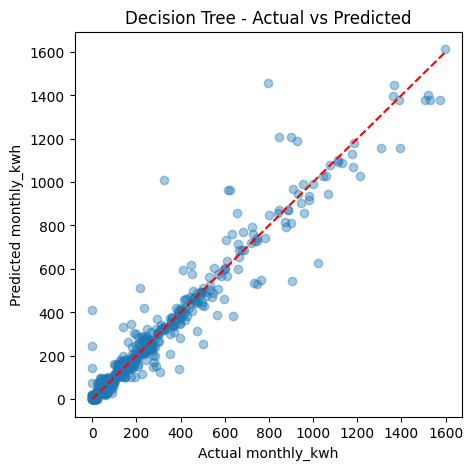

 38%|███▊      | 5/13 [00:01<00:02,  3.33it/s]

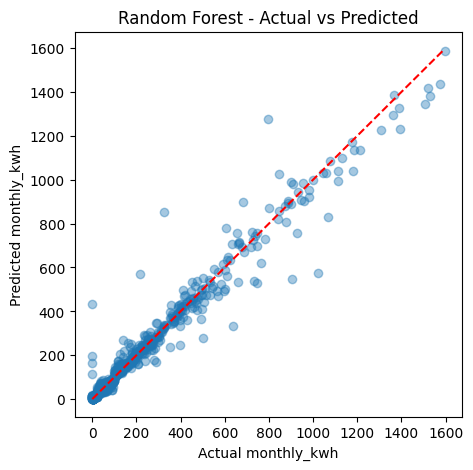

 46%|████▌     | 6/13 [00:04<00:09,  1.33s/it]

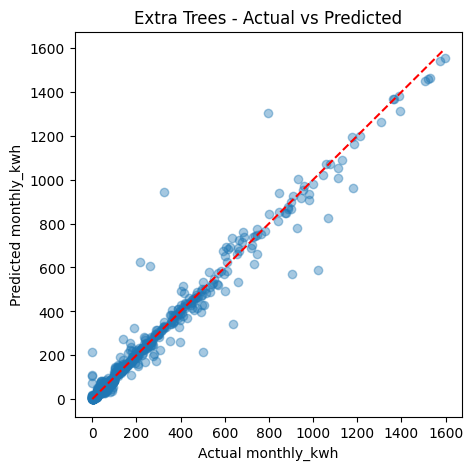

 54%|█████▍    | 7/13 [00:07<00:10,  1.79s/it]

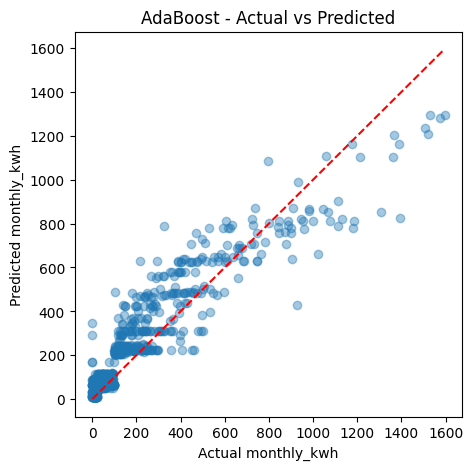

 62%|██████▏   | 8/13 [00:08<00:07,  1.42s/it]

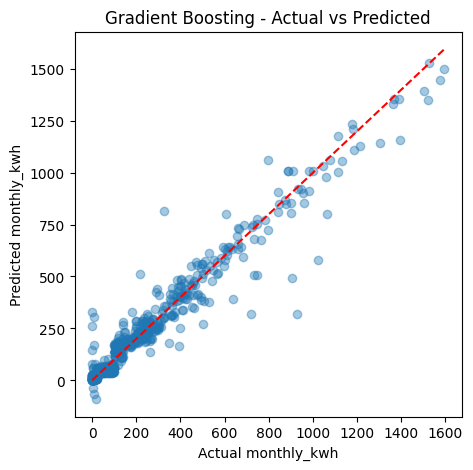

 69%|██████▉   | 9/13 [00:09<00:05,  1.26s/it]

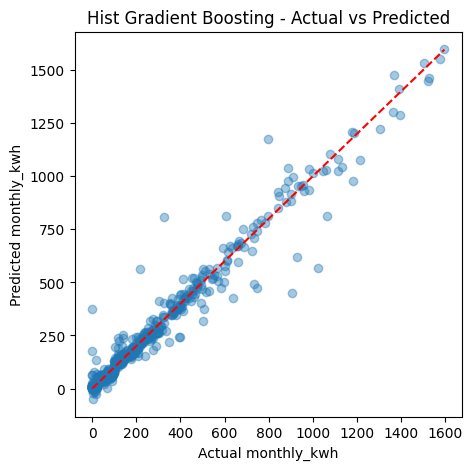

 77%|███████▋  | 10/13 [00:09<00:03,  1.06s/it]

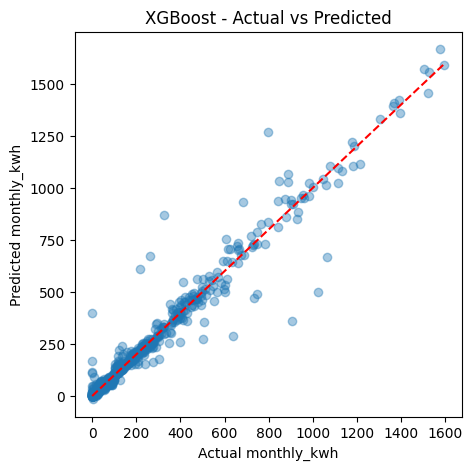

 85%|████████▍ | 11/13 [00:10<00:01,  1.17it/s]

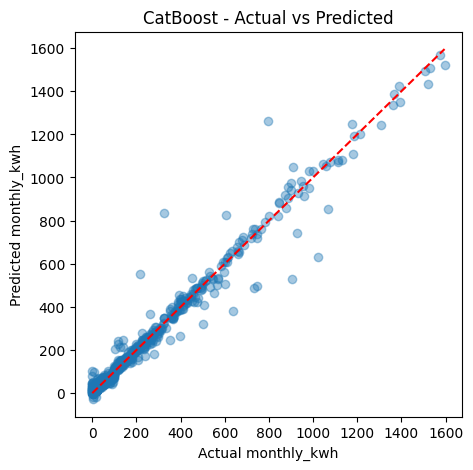

 92%|█████████▏| 12/13 [00:13<00:01,  1.51s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 531
[LightGBM] [Info] Number of data points in the train set: 6288, number of used features: 20
[LightGBM] [Info] Start training from score 107.025630


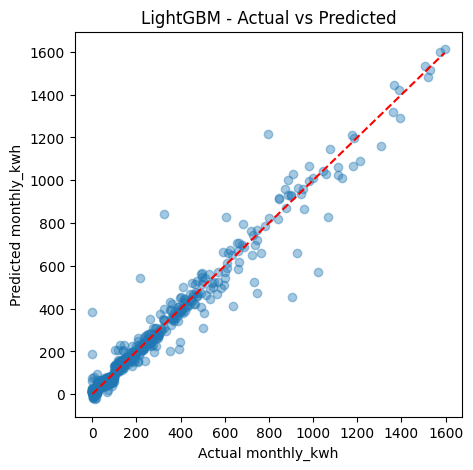

100%|██████████| 13/13 [00:13<00:00,  1.05s/it]


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
CatBoost,7.328789,10.463051,18.737330,32.603893,0.990836,0.976738
Extra Trees,0.012680,10.321909,0.554724,36.416598,0.999992,0.970979
Hist Gradient Boosting,10.520809,13.338821,27.379939,37.468986,0.980432,0.969277
LightGBM,10.329149,13.663963,26.779321,37.705209,0.981281,0.968889
Random Forest,4.380946,11.642511,16.331238,38.436419,0.993038,0.967670
XGBoost,4.386107,12.218880,9.359584,42.120751,0.997713,0.961175
Gradient Boosting,18.387673,20.792742,39.955881,45.895146,0.958328,0.953906
Decision Tree,0.012680,14.720527,0.554724,47.395730,0.999992,0.950842
KNN,22.365470,29.512285,57.248159,72.258375,0.914453,0.885741
AdaBoost,50.091490,51.459833,77.486590,81.709711,0.843276,0.853896


In [108]:
results = {}
for name, model in tqdm(models.items()):
    model.fit(X_train_fs, y_train)
    train_pred = model.predict(X_train_fs)
    test_pred  = model.predict(X_test_fs)

    results[name] = {
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
    }

    plt.figure(figsize=(5,5))
    plt.scatter(y_test, test_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual monthly_kwh")
    plt.ylabel("Predicted monthly_kwh")
    plt.title(f"{name} - Actual vs Predicted")
    plt.show()

results_df = pd.DataFrame(results).T.sort_values("Test R2", ascending=False)
display(results_df)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
CatBoost,7.328789,10.463051,18.737330,32.603893,0.990836,0.976738
Extra Trees,0.012680,10.321909,0.554724,36.416598,0.999992,0.970979
Hist Gradient Boosting,10.520809,13.338821,27.379939,37.468986,0.980432,0.969277
LightGBM,10.329149,13.663963,26.779321,37.705209,0.981281,0.968889
Random Forest,4.380946,11.642511,16.331238,38.436419,0.993038,0.967670
XGBoost,4.386107,12.218880,9.359584,42.120751,0.997713,0.961175
Gradient Boosting,18.387673,20.792742,39.955881,45.895146,0.958328,0.953906
Decision Tree,0.012680,14.720527,0.554724,47.395730,0.999992,0.950842
KNN,22.365470,29.512285,57.248159,72.258375,0.914453,0.885741
AdaBoost,50.091490,51.459833,77.486590,81.709711,0.843276,0.853896


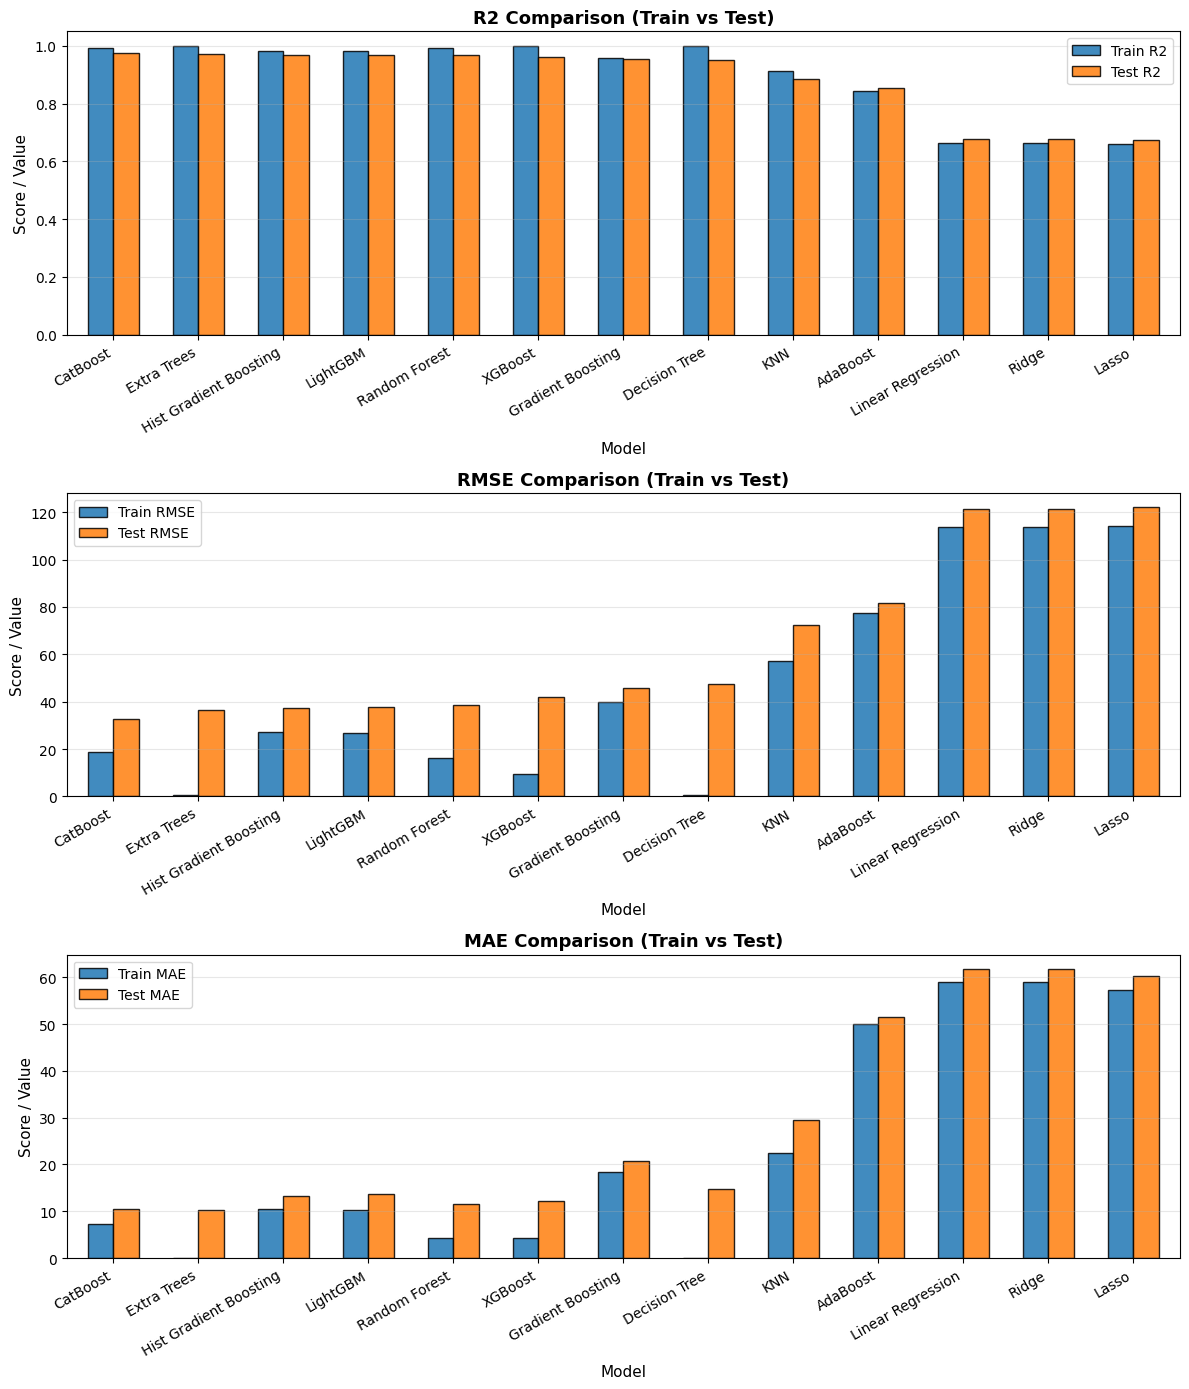

In [109]:
results_df = pd.DataFrame(results).T.sort_values(by="Test R2", ascending=False)
display(results_df)
cols = [
    ['Train R2', 'Test R2'],
    ['Train RMSE', 'Test RMSE'],
    ['Train MAE', 'Test MAE']
]

plt.figure(figsize=(12, 14))

for i, col_pair in enumerate(cols):
    ax = plt.subplot(3, 1, i+1)

    results_df[col_pair].plot(kind='bar', ax=ax, width=0.6, edgecolor='black', alpha=0.85)

    metric_name = col_pair[0].split(" ")[1]
    ax.set_title(f'{metric_name} Comparison (Train vs Test)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('Score / Value', fontsize=11)

    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='best')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

**Interpretation:** Sorting all trained models by Test R² gives a first ranking of model performance on the held-out test set, alongside Train R² (to spot overfitting when the train score is much higher than the test score).


In [110]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in tqdm(models.items()):
    scores = cross_val_score(model, X_train_fs, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = {
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T.sort_values("CV R2 Mean", ascending=False)
display(cv_results_df)

100%|██████████| 13/13 [00:40<00:00,  3.15s/it]


,CV R2 Mean,CV R2 Std
CatBoost,0.962801,0.009399
XGBoost,0.951083,0.013487
Extra Trees,0.949870,0.010334
Random Forest,0.948405,0.013861
Hist Gradient Boosting,0.947673,0.009619
LightGBM,0.947557,0.008961
Gradient Boosting,0.934841,0.016986
Decision Tree,0.885838,0.049721
KNN,0.850207,0.017179
AdaBoost,0.798515,0.027869


In [111]:
comparison_df = results_df[["Test R2"]].join(cv_results_df)
comparison_df = comparison_df.sort_values("CV R2 Mean", ascending=False)
display(comparison_df)
top3_names = comparison_df.index[:3].tolist()
print("Top 3 models based on CV R2 Mean:", top3_names)


,Test R2,CV R2 Mean,CV R2 Std
CatBoost,0.976738,0.962801,0.009399
XGBoost,0.961175,0.951083,0.013487
Extra Trees,0.970979,0.949870,0.010334
Random Forest,0.967670,0.948405,0.013861
Hist Gradient Boosting,0.969277,0.947673,0.009619
LightGBM,0.968889,0.947557,0.008961
Gradient Boosting,0.953906,0.934841,0.016986
Decision Tree,0.950842,0.885838,0.049721
KNN,0.885741,0.850207,0.017179
AdaBoost,0.853896,0.798515,0.027869


Top 3 models based on CV R2 Mean: ['CatBoost', 'XGBoost', 'Extra Trees']


**Interpretation:** Adding 5-fold cross-validated R² alongside the single-split Test R² gives a more robust estimate of each model's generalization performance, reducing the risk of a ranking that just happens to favor one particular train/test split.


In [112]:
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "Extra Trees": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0]
    },
    "CatBoost": {
        "iterations": [200, 400, 600],
        "depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1]
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.01, 0.05, 0.1]
    },
    "Hist Gradient Boosting": {
        "max_iter": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "learning_rate": [0.01, 0.05, 0.1]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"]
    }
}

tuned_models = {}
tuning_results = {}

for name in top3_names:
    base_model = models[name]
    grid = param_grids.get(name)

    if grid is None:
        tuned_models[name] = base_model
        continue

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=grid,
        n_iter=15,
        cv=kf,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train_fs, y_train)

    tuned_models[name] = search.best_estimator_
    tuning_results[name] = {
        "Best Params": search.best_params_,
        "Best CV R2": search.best_score_
    }

    print(f"{name} -> Best CV R2: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}\n")

CatBoost -> Best CV R2: 0.9638
Best Params: {'learning_rate': 0.1, 'iterations': 600, 'depth': 4}

XGBoost -> Best CV R2: 0.9589
Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}

Extra Trees -> Best CV R2: 0.9532
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}



In [113]:
tuned_test_results = {}
for name, model in tuned_models.items():
    train_pred = model.predict(X_train_fs)
    test_pred = model.predict(X_test_fs)
    tuned_test_results[name] = {
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
    }

tuned_test_df = pd.DataFrame(tuned_test_results).T.sort_values("Test R2", ascending=False)
display(tuned_test_df)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
CatBoost,9.808490,11.825182,26.344451,33.664872,0.981884,0.975199
Extra Trees,4.015069,10.765796,15.089038,36.738863,0.994057,0.970463
XGBoost,7.651683,12.349468,20.296247,38.307278,0.989247,0.967887


**Interpretation:** After hyperparameter tuning (via grid/randomized search) on the top candidate models, their train/test performance is re-evaluated to check whether tuning improved test performance without introducing overfitting.


Stacking base estimators: ['CatBoost', 'XGBoost', 'Extra Trees']
Stacking Model Performance
Train R2:  0.9854
Test R2:   0.9751
Train RMSE:23.6622
Test RMSE: 33.7073
Train MAE: 8.5840
Test MAE:  11.1850


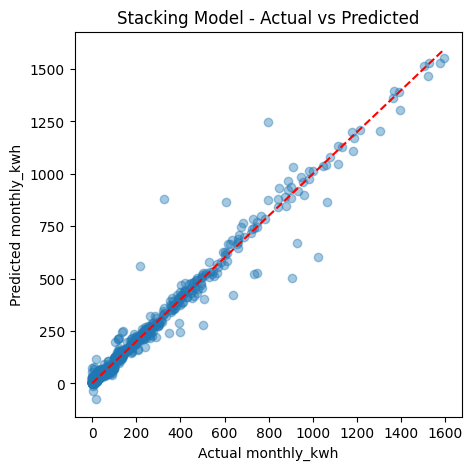

In [114]:

base_estimators = [(name, tuned_models[name]) for name in top3_names]
print("Stacking base estimators:", [name for name, _ in base_estimators])

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(random_state=42),
    cv=kf,
    n_jobs=-1
)

stacking_model.fit(X_train_fs, y_train)

train_pred = stacking_model.predict(X_train_fs)
test_pred = stacking_model.predict(X_test_fs)

print("Stacking Model Performance")
print(f"Train R2:  {r2_score(y_train, train_pred):.4f}")
print(f"Test R2:   {r2_score(y_test, test_pred):.4f}")
print(f"Train RMSE:{np.sqrt(mean_squared_error(y_train, train_pred)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, train_pred):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, test_pred):.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual monthly_kwh")
plt.ylabel("Predicted monthly_kwh")
plt.title("Stacking Model - Actual vs Predicted")
plt.show()

**Interpretation:** A `StackingRegressor` combines the top 3 tuned models as base learners with a `Ridge` meta-model, aiming to combine their complementary strengths into a single, typically more accurate, prediction.


## 12. Model Evaluation

In [115]:
final_comparison = tuned_test_df[["Test MAE", "Test RMSE", "Test R2"]].copy()
final_comparison.loc["Stacking (Top 3)"] = {
    "Test MAE": mean_absolute_error(y_test, test_pred),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "Test R2": r2_score(y_test, test_pred)
}
final_comparison = final_comparison.sort_values("Test R2", ascending=False)
display(final_comparison)

,Test MAE,Test RMSE,Test R2
CatBoost,11.825182,33.664872,0.975199
Stacking (Top 3),11.184954,33.707298,0.975136
Extra Trees,10.765796,36.738863,0.970463
XGBoost,12.349468,38.307278,0.967887


**Interpretation:** The final comparison table ranks all tuned individual models plus the stacking ensemble by Test MAE / RMSE / R², identifying the best-performing model for predicting `monthly_kwh`. The stacking model is expected to match or slightly exceed the best individual model, since it can rebalance the predictions of its base learners.

## Summary

- Raw text/placeholder values, negative values, and physically-impossible values were cleaned column by column.
- EDA showed a right-skewed target, appliance-type/room-driven usage patterns, and highlighted `watts` × `hours` as the key drivers of `monthly_kwh`.
- Features and target were separated, split into train/test, imputed, encoded, and scaled — with every fitted preprocessing object (`numeric_imputer.pkl`, `categorical_imputer.pkl`, `month_encoder.pkl`, `onehot_encoder.pkl`, `usage_level_encoder.pkl`, `is_heavy_appliance_encoder.pkl`, `robust_scaler.pkl`) saved to disk for consistent reuse at inference time.
- Multiple feature-selection methods agreed on a final, compact feature set.
- Several regression models were trained, cross-validated, tuned, and combined via stacking, with performance compared on Test MAE, RMSE and R².


## 13. Save Final Model and Deployment Artifacts

Looking at `final_comparison` (sorted by Test R²), the **Stacking (Top 3)** ensemble is the best-performing model — the highest Test R² and the lowest Test RMSE among all evaluated models. It is therefore selected as the final model and saved to disk, so it can be loaded later for inference without retraining. Note that this model expects its input to already be cleaned, imputed, encoded, scaled, and restricted to the selected feature set (`final_selected_features`) — i.e. all the preprocessing objects saved throughout this notebook must be applied first, in the same order.

Below, every artifact required to reproduce this pipeline in Streamlit is saved (or re-saved for a final, single source of truth), and a full end-to-end inference test simulates the real deployment workflow on one raw sample.

In [116]:
joblib.dump(stacking_model, "best_model.pkl")

['best_model.pkl']

### 13.1 Consolidated deployment artifacts

All preprocessing objects were already saved with `joblib` immediately after being fit (Section 9), and `selected_features.pkl` was saved right after the final feature set was determined (Section 10). The remaining pieces needed to reconstruct a valid input DataFrame from scratch — column lists/config and the `cost_per_kwh` outlier bound — are saved here.

In [117]:
feature_columns_config = {
    "raw_input_columns": raw_input_columns,       # columns a Streamlit form must collect
    "numeric_impute_cols": numeric_impute_cols,    # columns the numeric imputer expects
    "categorical_impute_cols": categorical_impute_cols,  # columns the categorical imputer expects
    "ohe_cols": ohe_cols,                          # columns the OneHotEncoder expects
    "scaled_columns": scaled_columns,              # exact column order the RobustScaler expects
    "final_selected_features": final_selected_features,  # exact column order the model expects
}
joblib.dump(feature_columns_config, "feature_columns_config.pkl")
joblib.dump(scaled_columns, "scaled_columns.pkl")
joblib.dump(cost_per_kwh_bounds, "cost_per_kwh_bounds.pkl")

print("Saved deployment artifacts:")
for fname in [
    "numeric_imputer.pkl", "categorical_imputer.pkl", "month_encoder.pkl",
    "onehot_encoder.pkl", "usage_level_encoder.pkl", "is_heavy_appliance_encoder.pkl",
    "robust_scaler.pkl", "best_model.pkl", "selected_features.pkl", "scaled_columns.pkl",
    "feature_columns_config.pkl", "cost_per_kwh_bounds.pkl",
]:
    print(" -", fname)

Saved deployment artifacts:
 - numeric_imputer.pkl
 - categorical_imputer.pkl
 - month_encoder.pkl
 - onehot_encoder.pkl
 - usage_level_encoder.pkl
 - is_heavy_appliance_encoder.pkl
 - robust_scaler.pkl
 - best_model.pkl
 - selected_features.pkl
 - scaled_columns.pkl
 - feature_columns_config.pkl
 - cost_per_kwh_bounds.pkl


### 13.2 Final feature-consistency check against the trained model

A last check ties Section 6's requirements together directly against the fitted `stacking_model`: the number of features it was trained on must match `len(final_selected_features)` exactly, for every one of its base estimators.

In [118]:
for name, est in stacking_model.estimators:
    n_expected = getattr(est, "n_features_in_", None)
    status = "OK" if (n_expected is None or n_expected == len(final_selected_features)) else "MISMATCH"
    print(f"{name:25s} n_features_in_={n_expected}  expected={len(final_selected_features)}  [{status}]")
    if n_expected is not None:
        assert n_expected == len(final_selected_features), f"{name} expects {n_expected} features, but final_selected_features has {len(final_selected_features)}!"
print("\nAll base estimators agree on the number of input features. No column mismatch expected at Streamlit inference time.")

CatBoost                  n_features_in_=20  expected=20  [OK]
XGBoost                   n_features_in_=20  expected=20  [OK]
Extra Trees               n_features_in_=20  expected=20  [OK]

All base estimators agree on the number of input features. No column mismatch expected at Streamlit inference time.


### 13.3 End-to-end deployment simulation (raw input → prediction)

This final test reproduces the *exact* Streamlit inference workflow, starting from one truly raw row re-read from the original CSV (not the in-memory `df`, which has already been mutated throughout this notebook) — exactly as a Streamlit app would receive a fresh row:

`Raw Input → Basic Cleaning → Feature Engineering → Numeric Imputation → Categorical Imputation → Month Encoding → One-Hot Encoding → usage_level Encoding → is_heavy_appliance Encoding → Robust Scaling → Select final_selected_features → best_model.predict`

Every object used below is the one that was just saved to disk — the test only proves the pipeline works if it is loaded exactly like the future Streamlit app would load it.

In [119]:
numeric_imputer_loaded = joblib.load("numeric_imputer.pkl")
categorical_imputer_loaded = joblib.load("categorical_imputer.pkl")
month_encoder_loaded = joblib.load("month_encoder.pkl")
onehot_encoder_loaded = joblib.load("onehot_encoder.pkl")
usage_level_encoder_loaded = joblib.load("usage_level_encoder.pkl")
is_heavy_appliance_encoder_loaded = joblib.load("is_heavy_appliance_encoder.pkl")
robust_scaler_loaded = joblib.load("robust_scaler.pkl")
best_model_loaded = joblib.load("best_model.pkl")
selected_features_loaded = joblib.load("selected_features.pkl")
feature_columns_config_loaded = joblib.load("feature_columns_config.pkl")
cost_per_kwh_bounds_loaded = joblib.load("cost_per_kwh_bounds.pkl")

raw_check_df = pd.read_csv(r'/content/electricity_dataset.csv')
sample_raw = raw_check_df.sample(1, random_state=42).reset_index(drop=True)
actual_value = pd.to_numeric(sample_raw["monthly_kwh"], errors="coerce").iloc[0]
sample_input = sample_raw[feature_columns_config_loaded["raw_input_columns"]].copy()

print("Raw sample input (as a Streamlit form would submit it):")
display(sample_input)

sample_clean = apply_basic_cleaning(sample_input, is_training=False, cost_bounds=cost_per_kwh_bounds_loaded)
sample_fe = apply_feature_engineering(sample_clean)

num_cols_infer = feature_columns_config_loaded["numeric_impute_cols"]
sample_fe[num_cols_infer] = numeric_imputer_loaded.transform(sample_fe[num_cols_infer])

cat_cols_infer = feature_columns_config_loaded["categorical_impute_cols"]
sample_fe[cat_cols_infer] = categorical_imputer_loaded.transform(sample_fe[cat_cols_infer])

sample_fe["month"] = sample_fe["month"].map(month_encoder_loaded)

ohe_cols_infer = feature_columns_config_loaded["ohe_cols"]
encoded_arr = onehot_encoder_loaded.transform(sample_fe[ohe_cols_infer])
encoded_df = pd.DataFrame(
    encoded_arr,
    columns=onehot_encoder_loaded.get_feature_names_out(ohe_cols_infer),
    index=sample_fe.index,
)
sample_fe = pd.concat([sample_fe.drop(columns=ohe_cols_infer), encoded_df], axis=1)

sample_fe["usage_level"] = sample_fe["usage_level"].map(usage_level_encoder_loaded)

sample_fe["is_heavy_appliance"] = sample_fe["is_heavy_appliance"].map(is_heavy_appliance_encoder_loaded)

scaled_columns_loaded = feature_columns_config_loaded["scaled_columns"]
for col in scaled_columns_loaded:
    if col not in sample_fe.columns:
        sample_fe[col] = 0
sample_fe = sample_fe[scaled_columns_loaded]
sample_fe[scaled_columns_loaded] = robust_scaler_loaded.transform(sample_fe[scaled_columns_loaded])

sample_final = sample_fe[selected_features_loaded]

prediction = best_model_loaded.predict(sample_final)[0]

print(f"\nPredicted monthly_kwh: {prediction:.2f}")
print(f"Actual monthly_kwh:    {actual_value:.2f}")
print("\nEnd-to-end deployment simulation succeeded: the saved artifacts are sufficient to go from a raw input row to a prediction, with no manual/notebook-only steps required.")

Raw sample input (as a Streamlit form would submit it):


,month,room_name,device_name,watts,hours,quantity,cost_per_kwh,usage_level,season,is_heavy_appliance
0,Aug,Dining Room,fan,78.0,11.1,1.0.0,8.0,medium,Summer,False



Predicted monthly_kwh: 26.73
Actual monthly_kwh:    25.97

End-to-end deployment simulation succeeded: the saved artifacts are sufficient to go from a raw input row to a prediction, with no manual/notebook-only steps required.


## Summary

- Raw text/placeholder values, negative values, and physically-impossible values were cleaned column by column, with only deterministic rules (Section 4).
- EDA showed a right-skewed target, appliance-type/room-driven usage patterns, and highlighted `watts` × `hours` as the key drivers of `monthly_kwh` (Section 5).
- No additional features are engineered beyond cleaning (Section 6) — the modeling methodology is unchanged.
- Features and target were separated, split into train/test, imputed, encoded, and scaled — with every fitted preprocessing object fit on `X_train` only and saved with `joblib` for consistent reuse at inference time (Sections 7–9).
- Multiple feature-selection methods agreed on a final, compact feature set, saved and validated for consistency (Section 10).
- Several regression models were trained, cross-validated, tuned, and combined via stacking, with performance compared on Test MAE, RMSE and R² (Sections 11–12).
- The final Stacking model and every deployment artifact were saved, and a full raw-input-to-prediction simulation confirmed the saved artifacts are sufficient for Streamlit deployment (Section 13).


In [129]:
import sklearn
import joblib

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.6.1
joblib: 1.5.3
